<a href="https://colab.research.google.com/github/EverHernandez01/Teoria_de_se-ales/blob/main/Modulacion_Demodulacion_AM/AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

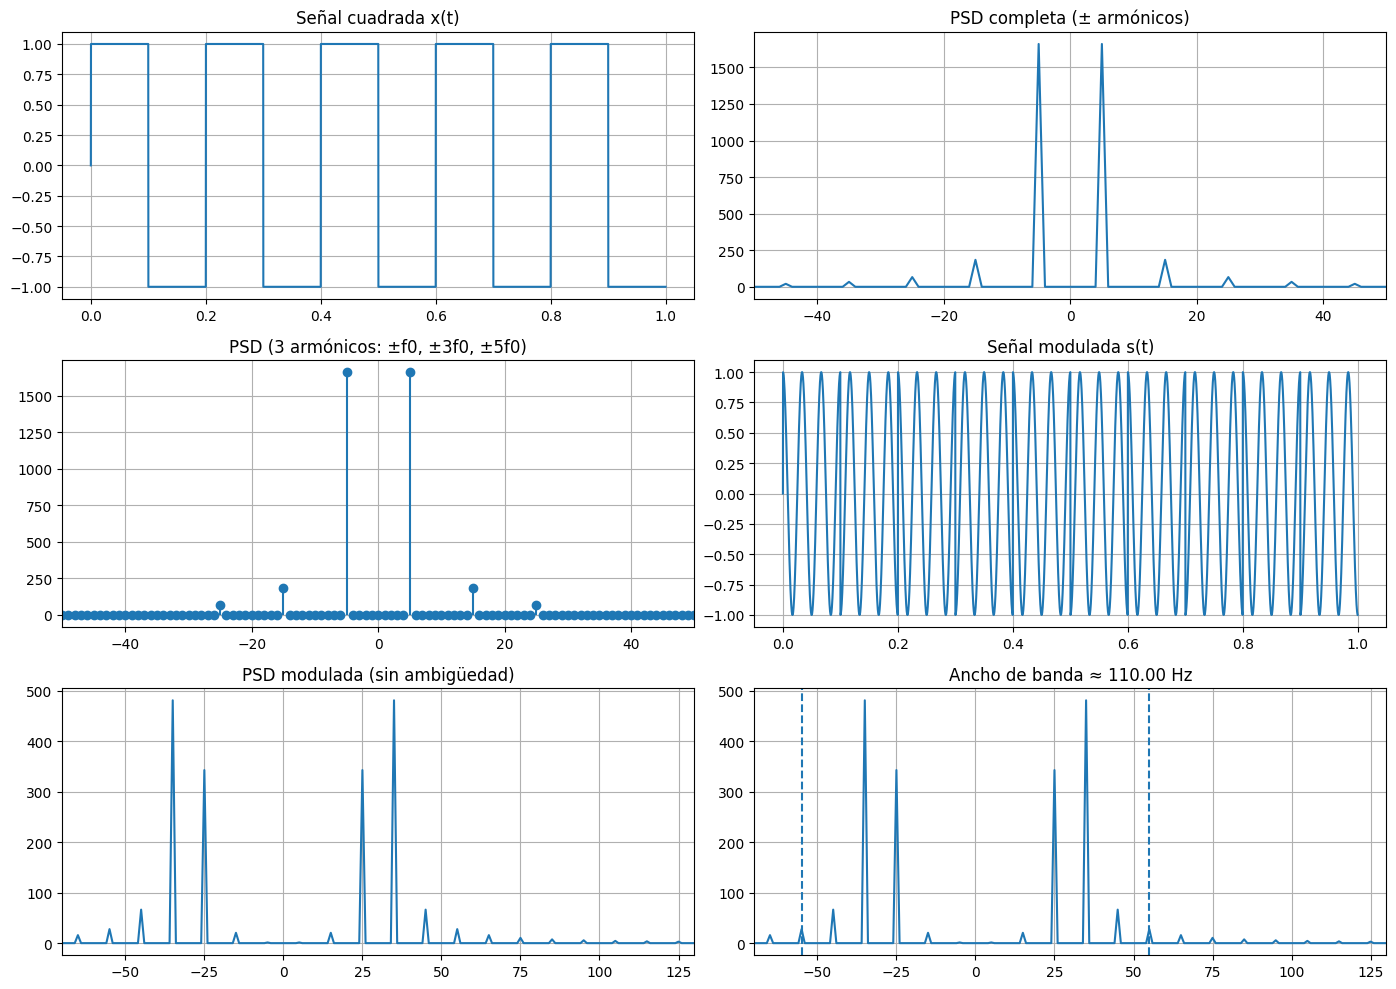

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARÁMETROS
# =========================
fs = 4096              # frecuencia de muestreo
N = 4096               # número de muestras
t = np.arange(N)/fs

f0 = 5                 # frecuencia fundamental (Hz)

# resolución en frecuencia
df = fs/N
dw = 2*np.pi*df

# Portadora (alineada al grid)
K = 30
fc = K*df              # equivalente a wc = K*dw

# =========================
# ETAPA 1: SEÑAL CUADRADA
# =========================
x = np.sign(np.sin(2*np.pi*f0*t))

# =========================
# FFT y PSD
# =========================
X = np.fft.fftshift(np.fft.fft(x))
f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
PSD_x = np.abs(X)**2 / N

# =========================
# FILTRAR SOLO 3 ARMÓNICOS
# =========================
# (solo para visualización)
mask = (
    (np.abs(np.abs(f) - f0) < 0.5) |
    (np.abs(np.abs(f) - 3*f0) < 0.5) |
    (np.abs(np.abs(f) - 5*f0) < 0.5)
)

PSD_3 = PSD_x * mask

# =========================
# ETAPA 2: MODULACIÓN
# =========================
c = np.cos(2*np.pi*fc*t)
s = x * c

# FFT modulada
S = np.fft.fftshift(np.fft.fft(s))
PSD_s = np.abs(S)**2 / N

# =========================
# ANCHO DE BANDA
# =========================
# buscamos donde hay energía significativa
threshold = 0.05*np.max(PSD_s)
band = f[PSD_s > threshold]

BW = np.max(band) - np.min(band)

# =========================
# GRAFICAS
# =========================
fig, axs = plt.subplots(3, 2, figsize=(14,10))

# 1. Señal en el tiempo
axs[0,0].plot(t, x)
axs[0,0].set_title("Señal cuadrada x(t)")
axs[0,0].grid()

# 2. PSD completa
axs[0,1].plot(f, PSD_x)
axs[0,1].set_title("PSD completa (± armónicos)")
axs[0,1].set_xlim(-50, 50)
axs[0,1].grid()

# 3. PSD con 3 armónicos
axs[1,0].stem(f, PSD_3, basefmt=" ")
axs[1,0].set_title("PSD (3 armónicos: ±f0, ±3f0, ±5f0)")
axs[1,0].set_xlim(-50, 50)
axs[1,0].grid()

# 4. Señal modulada en el tiempo
axs[1,1].plot(t, s)
axs[1,1].set_title("Señal modulada s(t)")
axs[2,0].set_xlim(fc - 100, fc + 100)
axs[1,1].grid()

# 5. PSD modulada
axs[2,0].plot(f, PSD_s)
axs[2,0].set_title("PSD modulada (sin ambigüedad)")
axs[2,0].set_xlim(fc - 100, fc + 100)
axs[2,0].grid()

# 6. Ancho de banda
axs[2,1].plot(f, PSD_s)
axs[2,1].axvline(np.min(band), linestyle='--')
axs[2,1].axvline(np.max(band), linestyle='--')
axs[2,1].set_title(f"Ancho de banda ≈ {BW:.2f} Hz")
axs[2,1].set_xlim(fc - 100, fc + 100)
axs[2,1].grid()

plt.tight_layout()
plt.show()

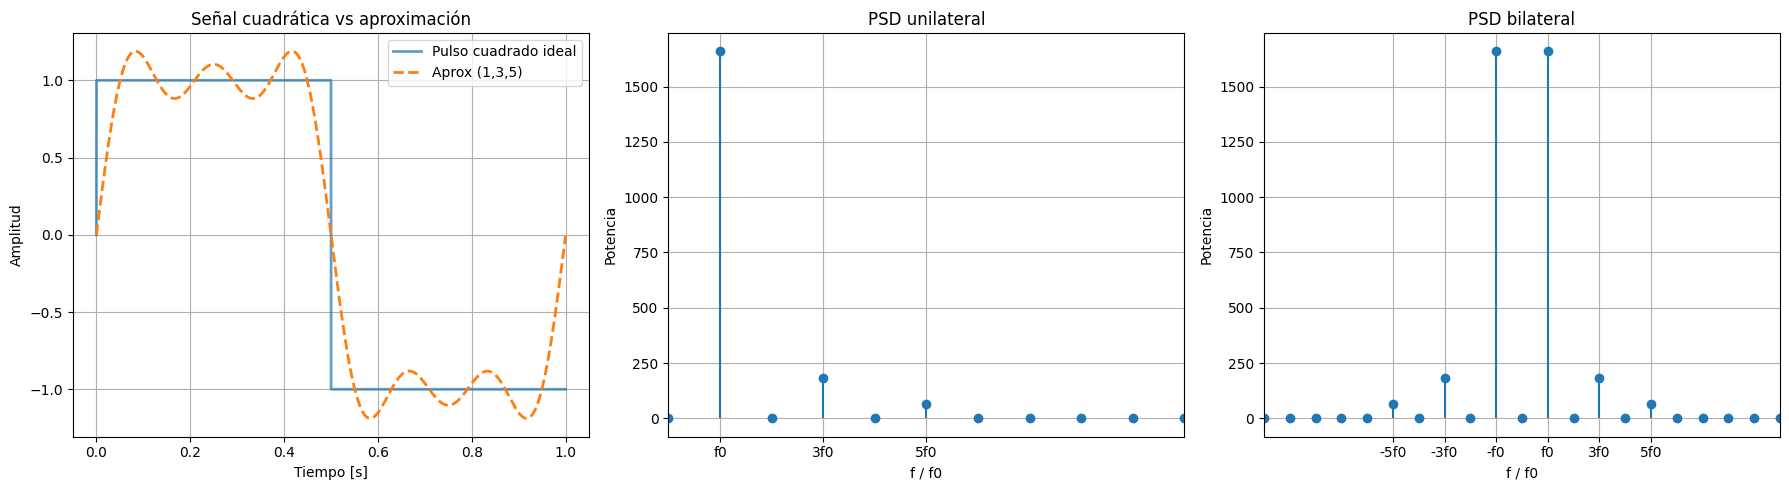

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2 * np.pi * f0

# =========================
# Señal ideal (cuadrada)
# =========================
x_square = np.sign(np.sin(w0 * t))

# =========================
# Señal aproximada (3 armónicos)
# =========================
x_approx = (4/np.pi) * (
    np.sin(w0 * t) +
    (1/3)*np.sin(3*w0 * t) +
    (1/5)*np.sin(5*w0 * t)
)

# =========================
# FFT
# =========================
Xf = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)

# =========================
# PSD unilateral
# =========================
mask = freqs >= 0
freqs_pos = freqs[mask]
Xf_pos = Xf[mask]

PSD_pos = (1/N) * np.abs(Xf_pos)**2
freqs_norm_pos = freqs_pos / f0

# =========================
# PSD bilateral
# =========================
Xf_shift = np.fft.fftshift(Xf)
freqs_shift = np.fft.fftshift(freqs)

PSD_bi = (1/N) * np.abs(Xf_shift)**2
freqs_norm_bi = freqs_shift / f0

# =========================
# FIGURA 1x3
# =========================
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# --------- (1) Señal en tiempo ---------
axs[0].plot(t, x_square, label='Pulso cuadrado ideal', linewidth=2, alpha=0.7)
axs[0].plot(t, x_approx, '--', label='Aprox (1,3,5)', linewidth=2)

axs[0].set_title('Señal cuadrática vs aproximación')
axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel('Amplitud')
axs[0].legend()
axs[0].grid()

# --------- (2) PSD unilateral ---------
axs[1].stem(freqs_norm_pos, PSD_pos, basefmt=" ")
axs[1].set_xlim(0, 10)
axs[1].set_title('PSD unilateral')
axs[1].set_xlabel('f / f0')
axs[1].set_ylabel('Potencia')
axs[1].set_xticks([1, 3, 5])
axs[1].set_xticklabels(['f0', '3f0', '5f0'])
axs[1].grid()

# --------- (3) PSD bilateral ---------
axs[2].stem(freqs_norm_bi, PSD_bi, basefmt=" ")
axs[2].set_xlim(-10, 10)
axs[2].set_title('PSD bilateral')
axs[2].set_xlabel('f / f0')
axs[2].set_ylabel('Potencia')
axs[2].set_xticks([-5, -3, -1, 1, 3, 5])
axs[2].set_xticklabels(['-5f0','-3f0','-f0','f0','3f0','5f0'])
axs[2].grid()

plt.tight_layout()
plt.show()

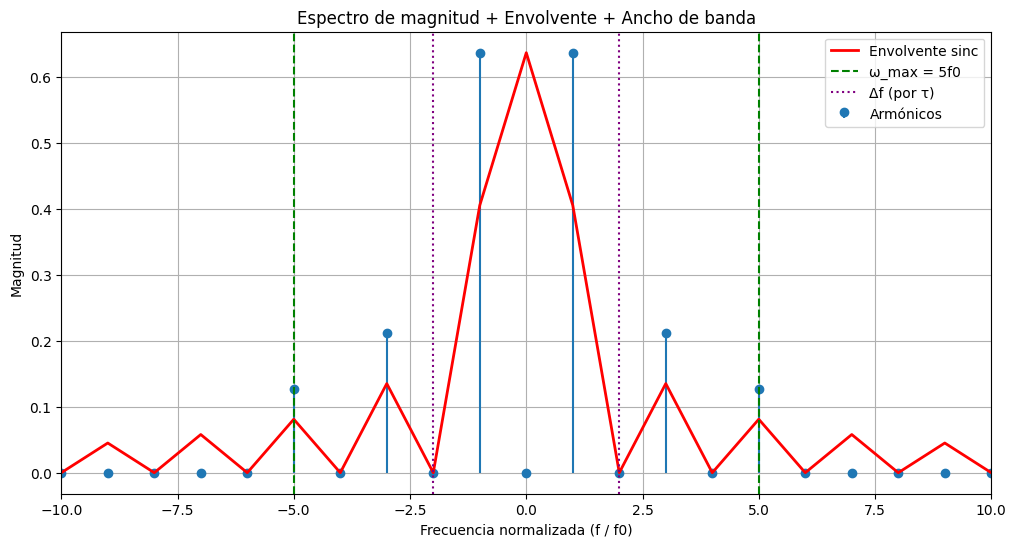

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2 * np.pi * f0

tau = 0.5  # ancho del pulso (50%)

# =========================
# Señal (3 armónicos)
# =========================
x = (4/np.pi) * (
    np.sin(w0 * t) +
    (1/3)*np.sin(3*w0 * t) +
    (1/5)*np.sin(5*w0 * t)
)

# =========================
# FFT
# =========================
Xf = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)

# Centrar espectro
Xf_shift = np.fft.fftshift(Xf)
freqs_shift = np.fft.fftshift(freqs)

# Magnitud
mag = np.abs(Xf_shift) / N

# Normalizar eje
f_norm = freqs_shift / f0

# =========================
# Envolvente tipo sinc
# =========================
# sinc en frecuencia: sinc(f * tau)
sinc_env = np.abs(np.sinc(freqs_shift * tau))

# Escalar para que coincida visualmente
sinc_env = sinc_env / np.max(sinc_env) * np.max(mag)

# =========================
# Anchos de banda
# =========================
f_max = 5  # 5*f0

delta_w = 2*np.pi / tau
delta_f = delta_w / (2*np.pi)  # convertir a Hz

# =========================
# Gráfica
# =========================
plt.figure(figsize=(12,6))

# Espectro discreto
plt.stem(f_norm, mag, basefmt=" ", label='Armónicos')

# Envolvente sinc
plt.plot(f_norm, sinc_env, 'r', linewidth=2, label='Envolvente sinc')

# Líneas de ancho de banda
plt.axvline(f_max, color='g', linestyle='--', label='ω_max = 5f0')
plt.axvline(-f_max, color='g', linestyle='--')

plt.axvline(delta_f, color='purple', linestyle=':', label='Δf (por τ)')
plt.axvline(-delta_f, color='purple', linestyle=':')

plt.xlim(-10, 10)

plt.title('Espectro de magnitud + Envolvente + Ancho de banda')
plt.xlabel('Frecuencia normalizada (f / f0)')
plt.ylabel('Magnitud')

plt.legend()
plt.grid()

plt.show()

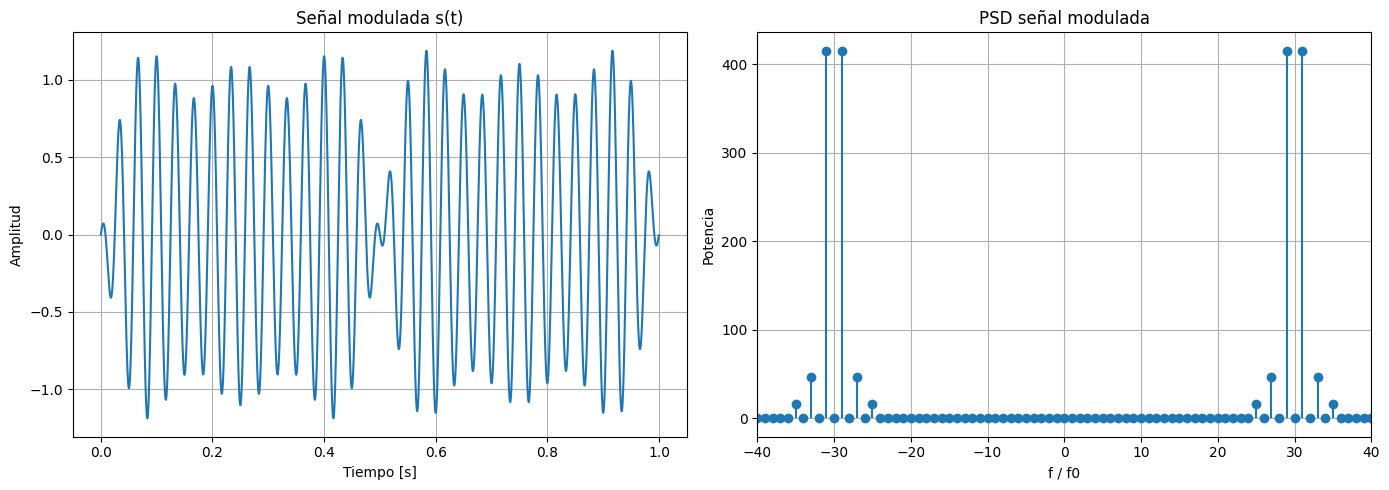

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2 * np.pi * f0

# =========================
# Señal base (3 armónicos)
# =========================
x = (4/np.pi) * (
    np.sin(w0 * t) +
    (1/3)*np.sin(3*w0 * t) +
    (1/5)*np.sin(5*w0 * t)
)

# =========================
# Portadora
# =========================
k = 30
fc = k * f0
wc = 2 * np.pi * fc

c = np.cos(wc * t)

# =========================
# Modulación DSB-SC
# =========================
s = x * c

# =========================
# FFT señal modulada
# =========================
S = np.fft.fft(s)
freqs = np.fft.fftfreq(N, 1/fs)

# Centrar espectro
S_shift = np.fft.fftshift(S)
freqs_shift = np.fft.fftshift(freqs)

PSD = (1/N) * np.abs(S_shift)**2
freqs_norm = freqs_shift / f0

# =========================
# Gráficas
# =========================
fig, axs = plt.subplots(1, 2, figsize=(14,5))

# -------- Tiempo --------
axs[0].plot(t, s)
axs[0].set_title('Señal modulada s(t)')
axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel('Amplitud')
axs[0].grid()

# -------- PSD --------
axs[1].stem(freqs_norm, PSD, basefmt=" ")
axs[1].set_xlim(-40, 40)
axs[1].set_title('PSD señal modulada')
axs[1].set_xlabel('f / f0')
axs[1].set_ylabel('Potencia')

axs[1].grid()

plt.tight_layout()
plt.show()

axs[1].axvline(25, color='r', linestyle='--', label='fc - 5f0')
axs[1].axvline(35, color='r', linestyle='--', label='fc + 5f0')
axs[1].axvline(-25, color='r', linestyle='--')
axs[1].axvline(-35, color='r', linestyle='--')

axs[1].legend()

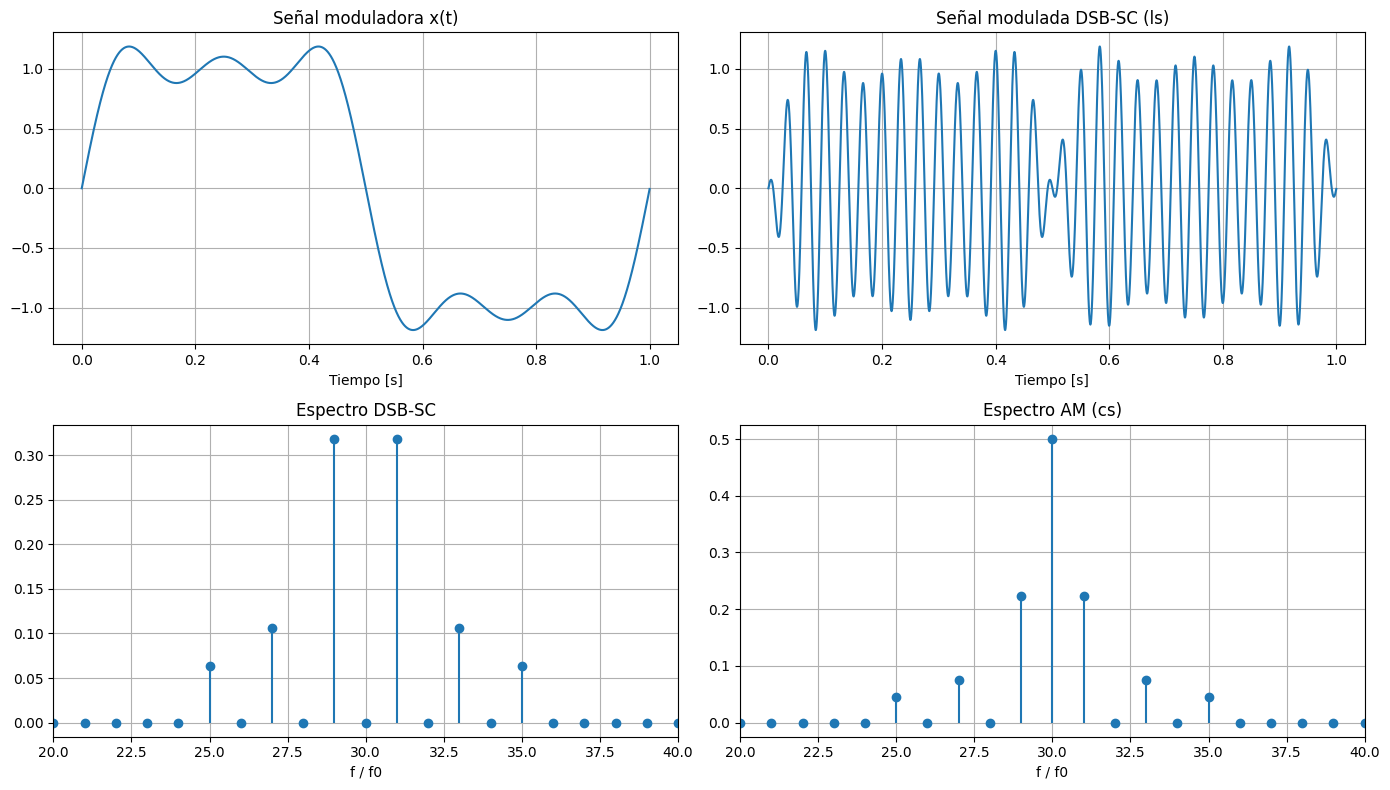

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros base
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2 * np.pi * f0

# Portadora (según PDF)
fc = 30 * f0
wc = 2 * np.pi * fc

m = 0.7  # índice de modulación (evitar sobre-modulación)

# =========================
# Señal moduladora (3 armónicos)
# =========================
x = (4/np.pi) * (
    np.sin(w0 * t) +
    (1/3)*np.sin(3*w0 * t) +
    (1/5)*np.sin(5*w0 * t)
)

# =========================
# Modulación
# =========================
s_sc = x * np.cos(wc * t)                  # DSB-SC (ls)
s_lc = (1 + m * x) * np.cos(wc * t)        # AM (cs)

# =========================
# FFT (bilateral)
# =========================
def spectrum(sig):
    X = np.fft.fft(sig)
    Xs = np.fft.fftshift(X)
    f = np.fft.fftfreq(len(sig), 1/fs)
    fs_ = np.fft.fftshift(f)
    mag = np.abs(Xs) / len(sig)
    return fs_, mag

f_x, mag_x = spectrum(x)
f_sc, mag_sc = spectrum(s_sc)
f_lc, mag_lc = spectrum(s_lc)

# Normalizar eje en f0
f_xn = f_x / f0
f_scn = f_sc / f0
f_lcn = f_lc / f0

# =========================
# Figura 2x2
# =========================
fig, axs = plt.subplots(2, 2, figsize=(14,8))

# (1) Señal moduladora
axs[0,0].plot(t, x)
axs[0,0].set_title('Señal moduladora x(t)')
axs[0,0].set_xlabel('Tiempo [s]')
axs[0,0].grid()

# (2) DSB-SC
axs[0,1].plot(t, s_sc)
axs[0,1].set_title('Señal modulada DSB-SC (ls)')
axs[0,1].set_xlabel('Tiempo [s]')
axs[0,1].grid()

# (3) Espectro DSB-SC
axs[1,0].stem(f_scn, mag_sc, basefmt=" ")
axs[1,0].set_xlim(20, 40)  # zoom alrededor de fc
axs[1,0].set_title('Espectro DSB-SC')
axs[1,0].set_xlabel('f / f0')
axs[1,0].grid()

# (4) Espectro AM (DSB-LC)
axs[1,1].stem(f_lcn, mag_lc, basefmt=" ")
axs[1,1].set_xlim(20, 40)
axs[1,1].set_title('Espectro AM (cs)')
axs[1,1].set_xlabel('f / f0')
axs[1,1].grid()

plt.tight_layout()
plt.show()

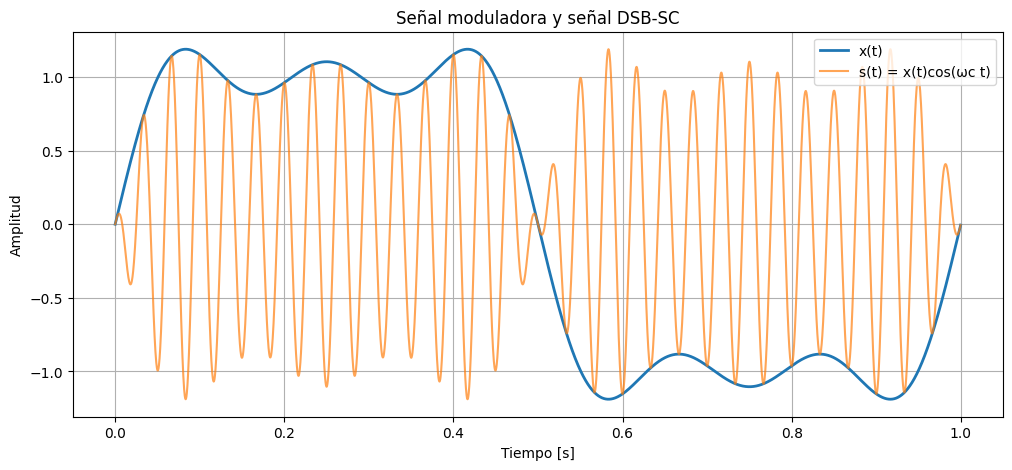

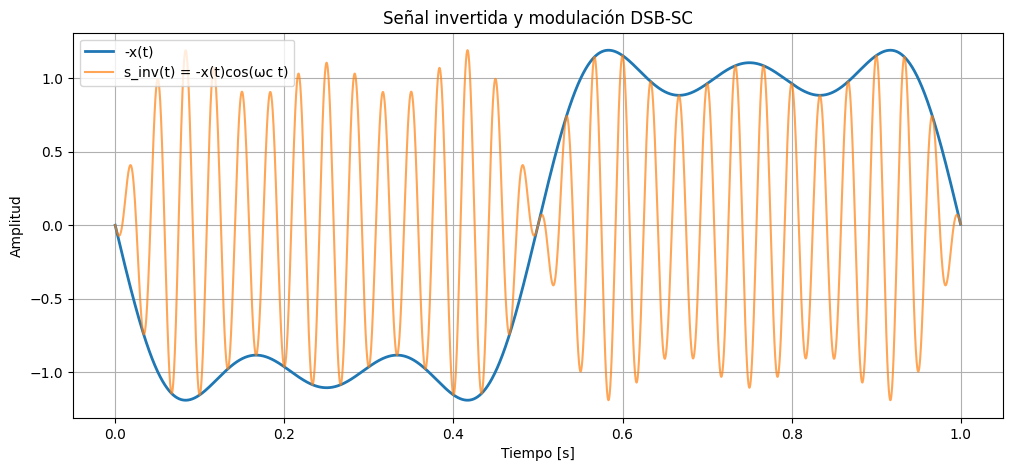

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2*np.pi*f0

fc = 30*f0
wc = 2*np.pi*fc

# =========================
# Señal moduladora
# =========================
x = (4/np.pi)*(
    np.sin(w0*t) +
    (1/3)*np.sin(3*w0*t) +
    (1/5)*np.sin(5*w0*t)
)

# Señal invertida
x_inv = -x

# =========================
# Modulación DSB-SC
# =========================
s = x * np.cos(wc*t)
s_inv = x_inv * np.cos(wc*t)

# =========================
# FIGURA 1 (normal)
# =========================
plt.figure(figsize=(12,5))

plt.plot(t, x, label='x(t)', linewidth=2)
plt.plot(t, s, label='s(t) = x(t)cos(ωc t)', alpha=0.7)

plt.title('Señal moduladora y señal DSB-SC')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')

plt.legend()
plt.grid()

plt.show()

# =========================
# FIGURA 2 (invertida)
# =========================
plt.figure(figsize=(12,5))

plt.plot(t, x_inv, label='-x(t)', linewidth=2)
plt.plot(t, s_inv, label='s_inv(t) = -x(t)cos(ωc t)', alpha=0.7)

plt.title('Señal invertida y modulación DSB-SC')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')

plt.legend()
plt.grid()

plt.show()

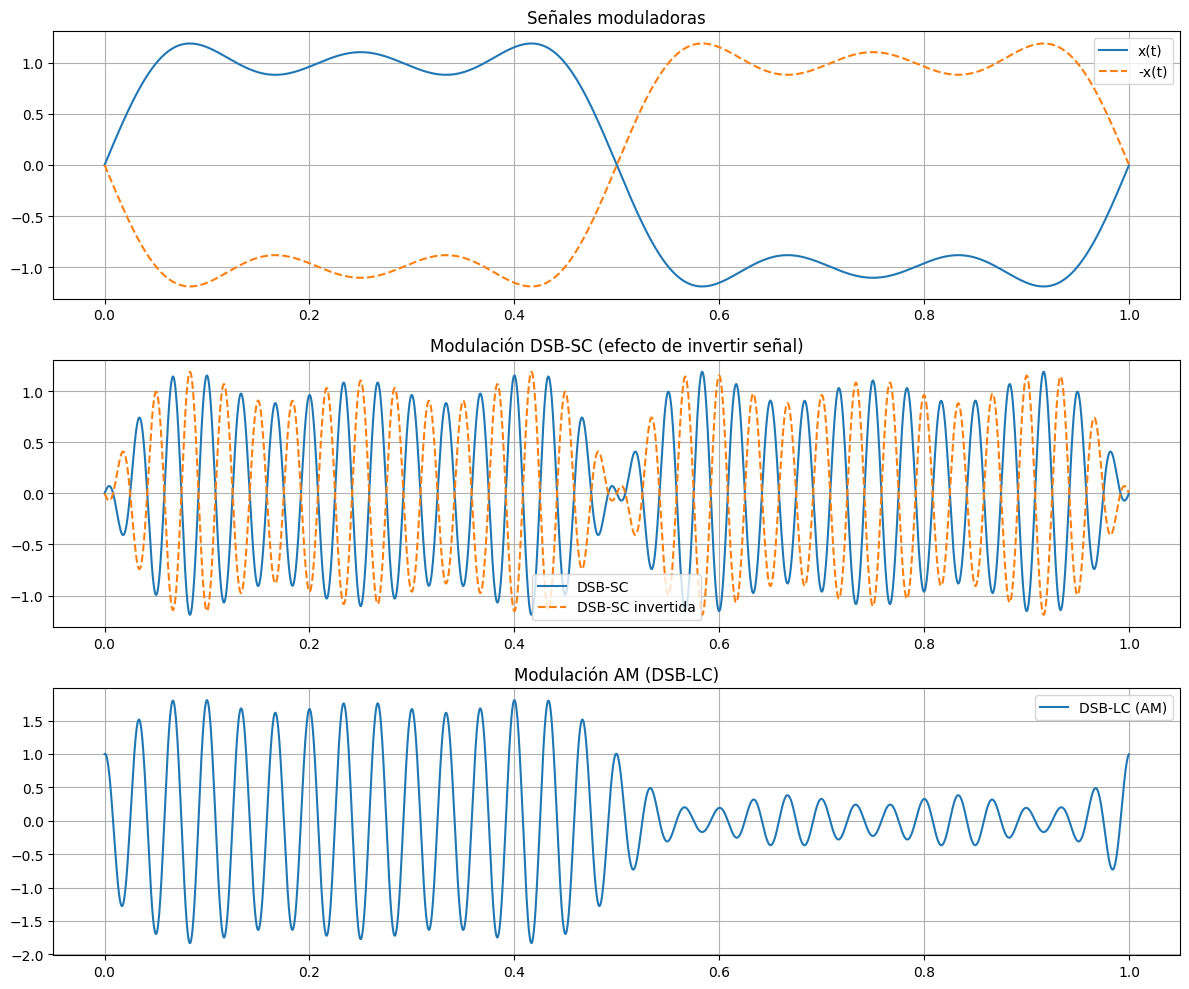

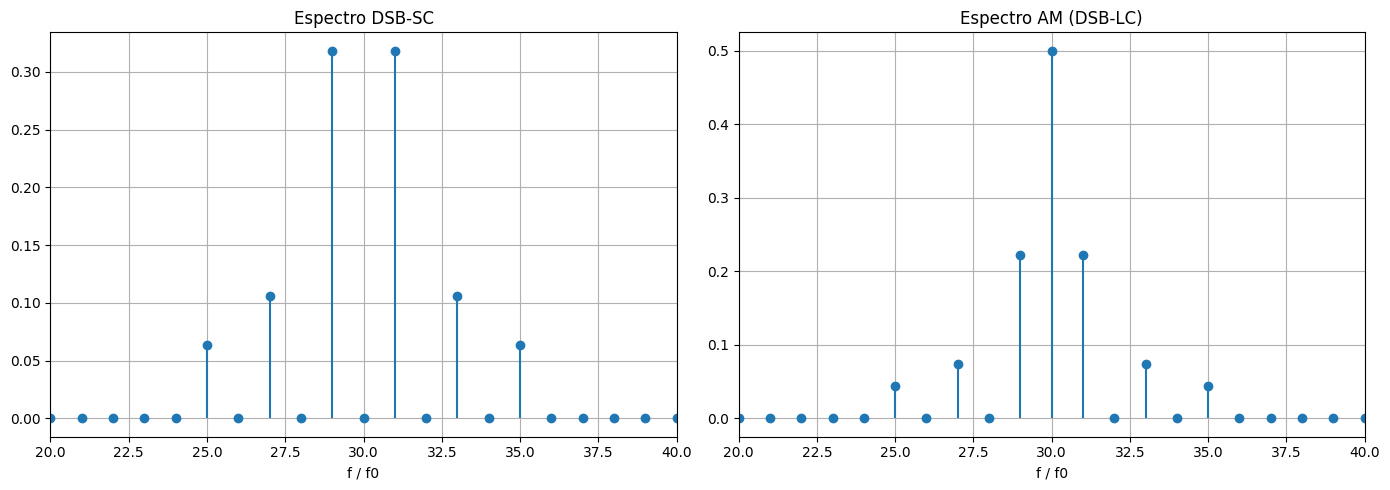

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2*np.pi*f0

fc = 30*f0
wc = 2*np.pi*fc

m = 0.7

# =========================
# Señal moduladora
# =========================
x = (4/np.pi)*(
    np.sin(w0*t) +
    (1/3)*np.sin(3*w0*t) +
    (1/5)*np.sin(5*w0*t)
)

x_inv = -x

# =========================
# Modulación
# =========================
# DSB-SC
s_sc = x * np.cos(wc*t)
s_sc_inv = x_inv * np.cos(wc*t)

# DSB-LC (AM)
s_lc = (1 + m*x) * np.cos(wc*t)

# =========================
# FFT
# =========================
def spectrum(sig):
    X = np.fft.fft(sig)
    Xs = np.fft.fftshift(X)
    f = np.fft.fftfreq(len(sig), 1/fs)
    fs_ = np.fft.fftshift(f)
    mag = np.abs(Xs)/len(sig)
    return fs_, mag

f_sc, mag_sc = spectrum(s_sc)
f_lc, mag_lc = spectrum(s_lc)

f_scn = f_sc / f0
f_lcn = f_lc / f0

# =========================
# FIGURA 1: TIEMPO
# =========================
fig1, axs = plt.subplots(3,1, figsize=(12,10))

# (1) Señales base
axs[0].plot(t, x, label='x(t)')
axs[0].plot(t, x_inv, '--', label='-x(t)')
axs[0].set_title('Señales moduladoras')
axs[0].legend()
axs[0].grid()

# (2) DSB-SC normal vs invertida
axs[1].plot(t, s_sc, label='DSB-SC')
axs[1].plot(t, s_sc_inv, '--', label='DSB-SC invertida')
axs[1].set_title('Modulación DSB-SC (efecto de invertir señal)')
axs[1].legend()
axs[1].grid()

# (3) DSB-LC (AM)
axs[2].plot(t, s_lc, label='DSB-LC (AM)')
axs[2].set_title('Modulación AM (DSB-LC)')
axs[2].legend()
axs[2].grid()

plt.tight_layout()
plt.show()

# =========================
# FIGURA 2: FRECUENCIA
# =========================
fig2, axs2 = plt.subplots(1,2, figsize=(14,5))

# (1) DSB-SC
axs2[0].stem(f_scn, mag_sc, basefmt=" ")
axs2[0].set_xlim(20, 40)
axs2[0].set_title('Espectro DSB-SC')
axs2[0].set_xlabel('f / f0')
axs2[0].grid()

# (2) DSB-LC
axs2[1].stem(f_lcn, mag_lc, basefmt=" ")
axs2[1].set_xlim(20, 40)
axs2[1].set_title('Espectro AM (DSB-LC)')
axs2[1].set_xlabel('f / f0')
axs2[1].grid()

plt.tight_layout()
plt.show()

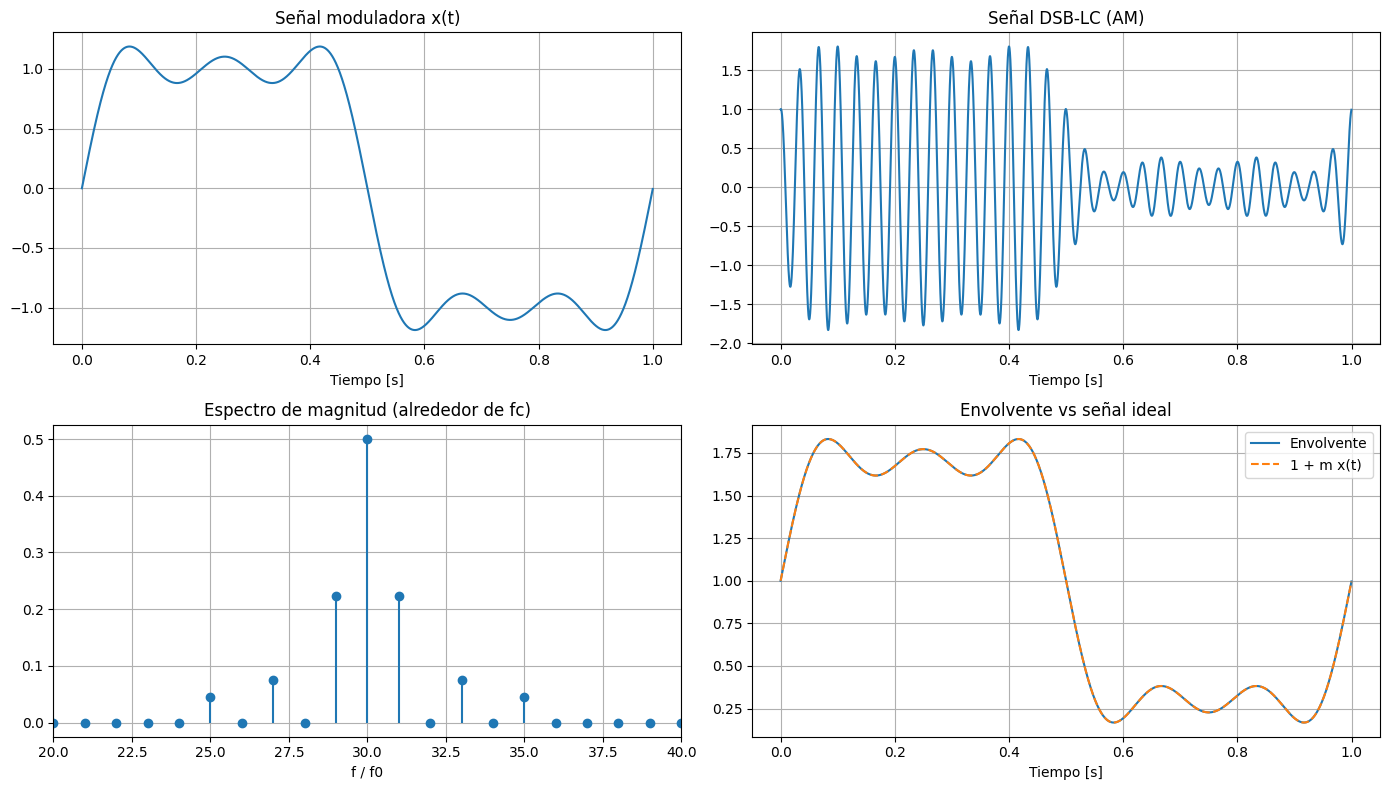

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T
t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2*np.pi*f0

fc = 30*f0
wc = 2*np.pi*fc

m = 0.7   # índice de modulación (estable)

# =========================
# Señal moduladora (3 armónicos)
# =========================
x = (4/np.pi)*(
    np.sin(w0*t) +
    (1/3)*np.sin(3*w0*t) +
    (1/5)*np.sin(5*w0*t)
)

# =========================
# DSB-LC (AM)
# =========================
s_lc = (1 + m*x) * np.cos(wc*t)

# =========================
# Envolvente (Hilbert)
# =========================
analytic = hilbert(s_lc)
env = np.abs(analytic)
env_ideal = 1 + m*x

# =========================
# Espectro (magnitud)
# =========================
X = np.fft.fft(s_lc)
Xs = np.fft.fftshift(X)

f = np.fft.fftfreq(N, 1/fs)
fs_shift = np.fft.fftshift(f)

mag = np.abs(Xs)/N
f_norm = fs_shift / f0

# =========================
# FIGURA 2x2
# =========================
fig, axs = plt.subplots(2,2, figsize=(14,8))

# (1) Señal moduladora
axs[0,0].plot(t, x)
axs[0,0].set_title('Señal moduladora x(t)')
axs[0,0].set_xlabel('Tiempo [s]')
axs[0,0].grid()

# (2) Señal AM
axs[0,1].plot(t, s_lc)
axs[0,1].set_title('Señal DSB-LC (AM)')
axs[0,1].set_xlabel('Tiempo [s]')
axs[0,1].grid()

# (3) Espectro
axs[1,0].stem(f_norm, mag, basefmt=" ")
axs[1,0].set_xlim(20, 40)
axs[1,0].set_title('Espectro de magnitud (alrededor de fc)')
axs[1,0].set_xlabel('f / f0')
axs[1,0].grid()

# (4) Envolvente
axs[1,1].plot(t, env, label='Envolvente')
axs[1,1].plot(t, env_ideal, '--', label='1 + m x(t)')
axs[1,1].set_title('Envolvente vs señal ideal')
axs[1,1].set_xlabel('Tiempo [s]')
axs[1,1].legend()
axs[1,1].grid()

plt.tight_layout()
plt.show()

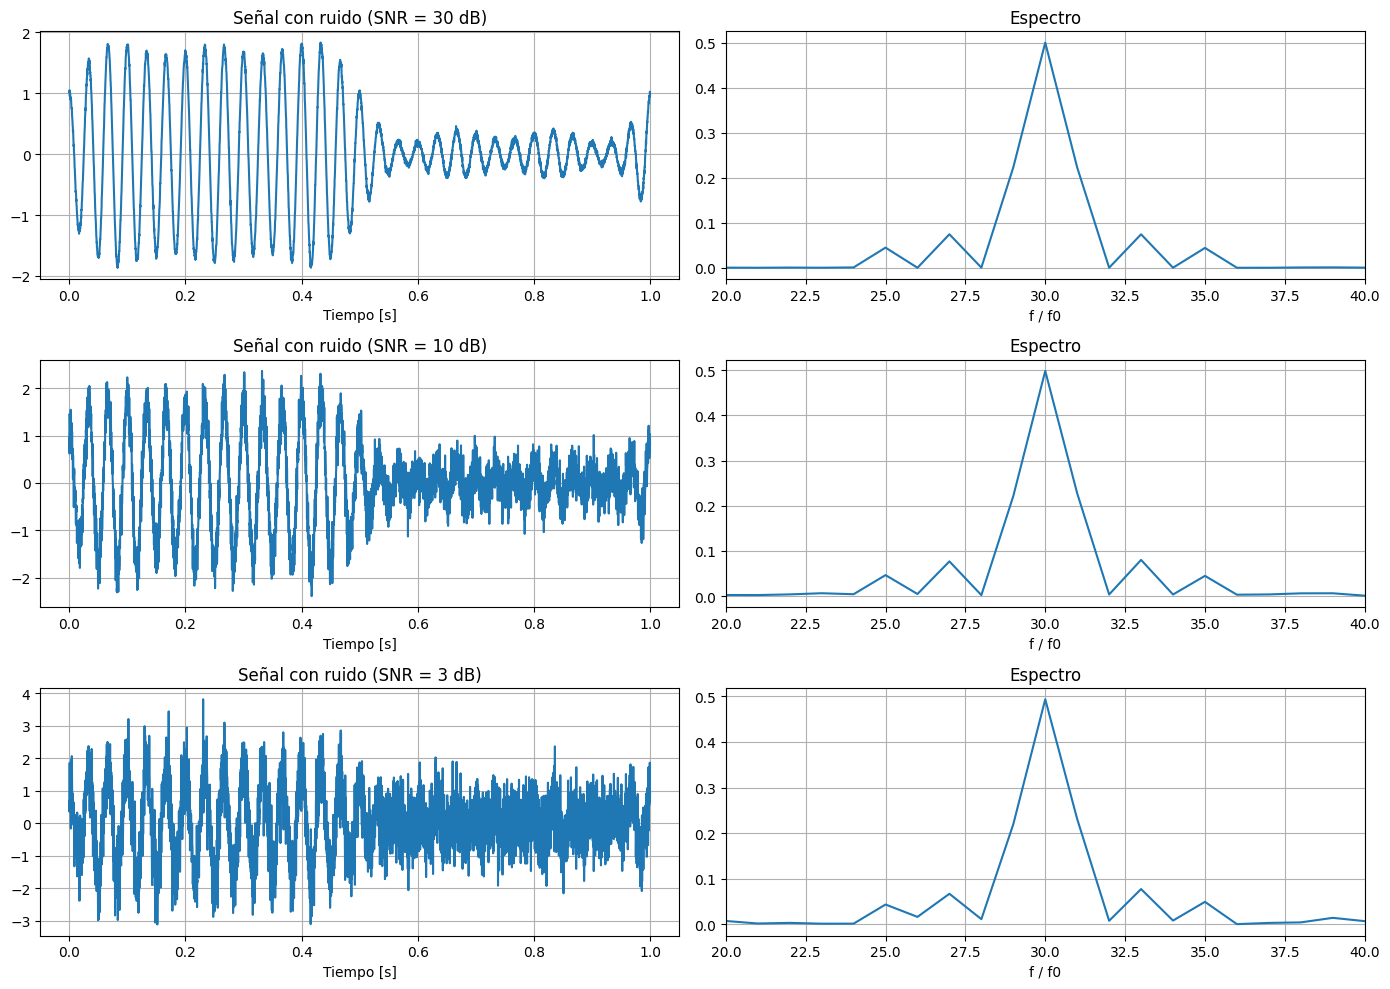

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2*np.pi*f0

fc = 30*f0
wc = 2*np.pi*fc

m = 0.7

# =========================
# Señal moduladora (3 armónicos)
# =========================
x = (4/np.pi)*(
    np.sin(w0*t) +
    (1/3)*np.sin(3*w0*t) +
    (1/5)*np.sin(5*w0*t)
)

# =========================
# Señal AM (DSB-LC)
# =========================
s = (1 + m*x) * np.cos(wc*t)

# =========================
# Potencia de la señal
# =========================
Ps = np.mean(s**2)

# =========================
# Función AWGN
# =========================
def add_awgn(signal, snr_db):
    Ps = np.mean(signal**2)
    snr_lin = 10**(snr_db/10)
    sigma2 = Ps / snr_lin
    noise = np.sqrt(sigma2) * np.random.randn(len(signal))
    return signal + noise

# Señales con ruido
snr_values = [30, 10, 3]
signals = [add_awgn(s, snr) for snr in snr_values]

# =========================
# FFT helper
# =========================
def spectrum(sig):
    X = np.fft.fft(sig)
    Xs = np.fft.fftshift(X)
    f = np.fft.fftfreq(len(sig), 1/fs)
    fs_ = np.fft.fftshift(f)
    mag = np.abs(Xs)/len(sig)
    return fs_, mag

# =========================
# FIGURA
# =========================
fig, axs = plt.subplots(3, 2, figsize=(14,10))

for i, snr in enumerate(snr_values):
    y = signals[i]

    # Tiempo
    axs[i,0].plot(t, y)
    axs[i,0].set_title(f'Señal con ruido (SNR = {snr} dB)')
    axs[i,0].set_xlabel('Tiempo [s]')
    axs[i,0].grid()

    # Espectro
    f, mag = spectrum(y)
    axs[i,1].plot(f/f0, mag)
    axs[i,1].set_xlim(20, 40)
    axs[i,1].set_title('Espectro')
    axs[i,1].set_xlabel('f / f0')
    axs[i,1].grid()

plt.tight_layout()
plt.show()

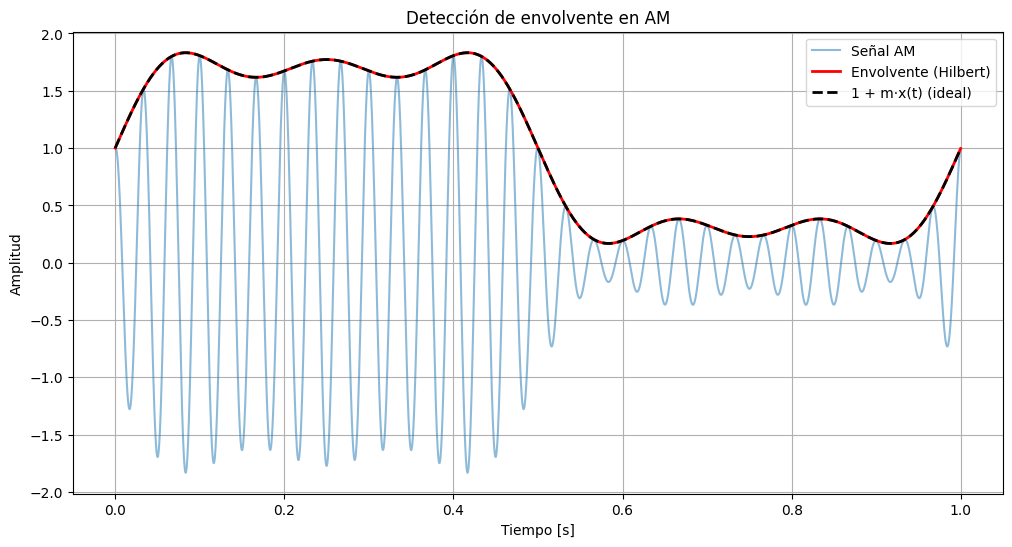

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# =========================
# Parámetros
# =========================
fs = 4096
T = 1
N = fs * T

t = np.linspace(0, T, N, endpoint=False)

f0 = 1
w0 = 2*np.pi*f0

fc = 30*f0
wc = 2*np.pi*fc

m = 0.7

# =========================
# Señal moduladora
# =========================
x = (4/np.pi)*(
    np.sin(w0*t) +
    (1/3)*np.sin(3*w0*t) +
    (1/5)*np.sin(5*w0*t)
)

# =========================
# Señal AM
# =========================
s = (1 + m*x) * np.cos(wc*t)

# =========================
# Envolvente (Hilbert)
# =========================
analytic_signal = hilbert(s)
envelope = np.abs(analytic_signal)

# Señal teórica esperada
ideal_env = 1 + m*x

# =========================
# Gráfica
# =========================
plt.figure(figsize=(12,6))

plt.plot(t, s, label='Señal AM', alpha=0.5)
plt.plot(t, envelope, 'r', linewidth=2, label='Envolvente (Hilbert)')
plt.plot(t, ideal_env, '--k', linewidth=2, label='1 + m·x(t) (ideal)')

plt.title('Detección de envolvente en AM')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')

plt.legend()
plt.grid()

plt.show()

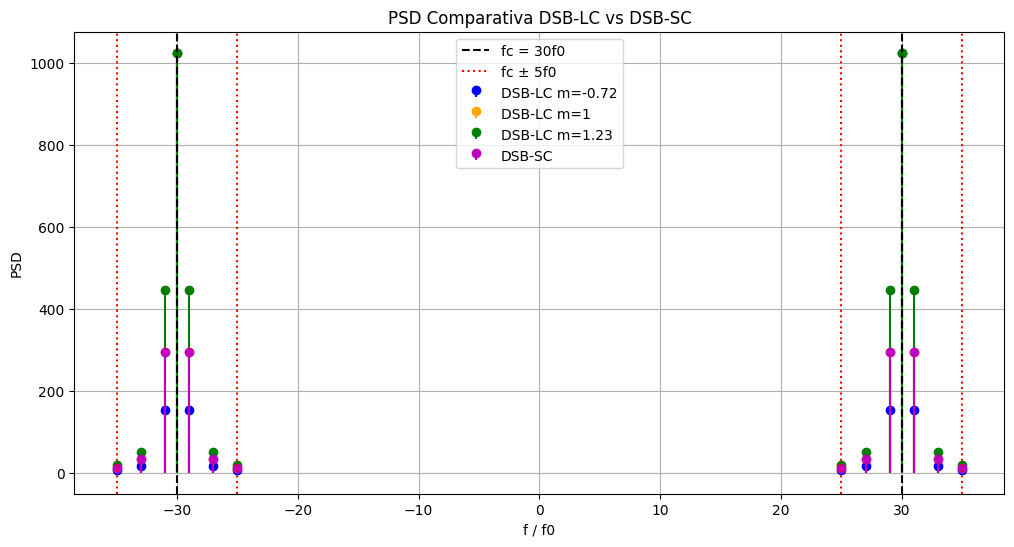

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS GENERALES
# =========================================================
N = 4096
n = np.arange(N)

f0 = 1 / N
w0 = 2 * np.pi / N

fc = 30 * f0
wc = 2 * np.pi * fc

M = 3
HM = [2*k + 1 for k in range(M)]  # [1, 3, 5]

# =========================================================
# FUNCIONES
# =========================================================

def generar_senal_moduladora(n, HM, w0):
    """Genera x[n] usando serie de Fourier truncada"""
    x = np.zeros_like(n, dtype=float)
    for k in HM:
        x += (1/k) * np.sin(k * w0 * n)
    return (4/np.pi) * x


def normalizar(x):
    """Normaliza señal a [-1,1]"""
    return x / np.max(np.abs(x))


def generar_portadora(n, fc):
    """Genera coseno portador"""
    return np.cos(2 * np.pi * fc * n)


def modulacion_dsb_lc(xn, carrier, m):
    """DSB-LC"""
    E = 1 + m * xn
    return E * carrier


def modulacion_dsb_sc(xn, carrier):
    """DSB-SC"""
    return xn * carrier


def calcular_psd(s):
    """PSD usando DFT"""
    S = np.fft.fft(s)
    S = np.fft.fftshift(S)
    return (np.abs(S)**2) / len(s)


def obtener_indices_frecuencia(N):
    """Eje de frecuencia normalizado"""
    return np.arange(-N//2, N//2)


def filtrar_componentes(psd, eps=1e-8):
    """Filtra componentes significativas"""
    return psd > eps * np.max(psd)


def plot_psd_stem(k, psd_list, labels, colors):
    """Gráfica PSD tipo líneas discretas"""
    plt.figure(figsize=(12,6))

    for psd, label, color in zip(psd_list, labels, colors):
        mask = filtrar_componentes(psd)

        markerline, stemlines, baseline = plt.stem(
            k[mask], psd[mask],
            basefmt=" ",
            label=label
        )

        plt.setp(markerline, marker='o', color=color)
        plt.setp(stemlines, color=color)

    # Líneas importantes
    plt.axvline(30, color='k', linestyle='--', label='fc = 30f0')
    plt.axvline(25, color='r', linestyle=':', label='fc ± 5f0')
    plt.axvline(35, color='r', linestyle=':')
    plt.axvline(-30, color='k', linestyle='--')
    plt.axvline(-25, color='r', linestyle=':')
    plt.axvline(-35, color='r', linestyle=':')

    plt.xlabel('f / f0')
    plt.ylabel('PSD')
    plt.title('PSD Comparativa DSB-LC vs DSB-SC')
    plt.legend()
    plt.grid()
    plt.show()


# =========================================================
# ETAPA 1: SEÑAL MODULADORA
# =========================================================
x = generar_senal_moduladora(n, HM, w0)
xn = normalizar(x)

# =========================================================
# ETAPA 2: MODULACIÓN
# =========================================================
carrier = generar_portadora(n, fc)

m_values = [-0.72, 1, 1.23]

s_LC = [modulacion_dsb_lc(xn, carrier, m) for m in m_values]
s_SC = modulacion_dsb_sc(xn, carrier)

# =========================================================
# PSD
# =========================================================
psd_LC = [calcular_psd(s) for s in s_LC]
psd_SC = calcular_psd(s_SC)

k = obtener_indices_frecuencia(N)

# =========================================================
# GRÁFICA FINAL
# =========================================================
psd_all = psd_LC + [psd_SC]
labels = [f'DSB-LC m={m}' for m in m_values] + ['DSB-SC']
colors = ['b', 'orange', 'g', 'm']

plot_psd_stem(k, psd_all, labels, colors)

def plot_psd_con_bw(k, psd, label, color, eps=1e-8):
    """
    Grafica PSD (unilateral) + ancho de banda resaltado
    """

    # Solo parte positiva
    mask_pos = k >= 0
    k_pos = k[mask_pos]
    psd_pos = psd[mask_pos]

    # Componentes significativas
    mask = psd_pos > eps * np.max(psd_pos)
    k_sig = k_pos[mask]

    k_sig = np.sort(k_sig)

    f_min = k_sig[0]
    f_max = k_sig[-1]
    B = f_max - f_min

    plt.figure(figsize=(12,6))

    # PSD tipo stem
    markerline, stemlines, baseline = plt.stem(
        k_pos[mask], psd_pos[mask],
        basefmt=" ",
        label=label
    )

    plt.setp(markerline, marker='o', color=color)
    plt.setp(stemlines, color=color)

    # Líneas de ancho de banda
    plt.axvline(f_min, color='r', linestyle='--', label=f'f_min={f_min}')
    plt.axvline(f_max, color='r', linestyle='--', label=f'f_max={f_max}')

    # Región sombreada
    plt.axvspan(f_min, f_max, color='red', alpha=0.1)

    # Etiqueta del ancho de banda
    plt.text((f_min+f_max)/2, max(psd_pos)*0.8,
             f'B = {B} f0',
             horizontalalignment='center',
             color='red',
             fontsize=12)

    plt.xlabel('f / f0')
    plt.ylabel('PSD')
    plt.title(f'{label} con Ancho de Banda')
    plt.legend()
    plt.grid()

    plt.show()

    return f_min, f_max, B


====== RESULTADOS ======



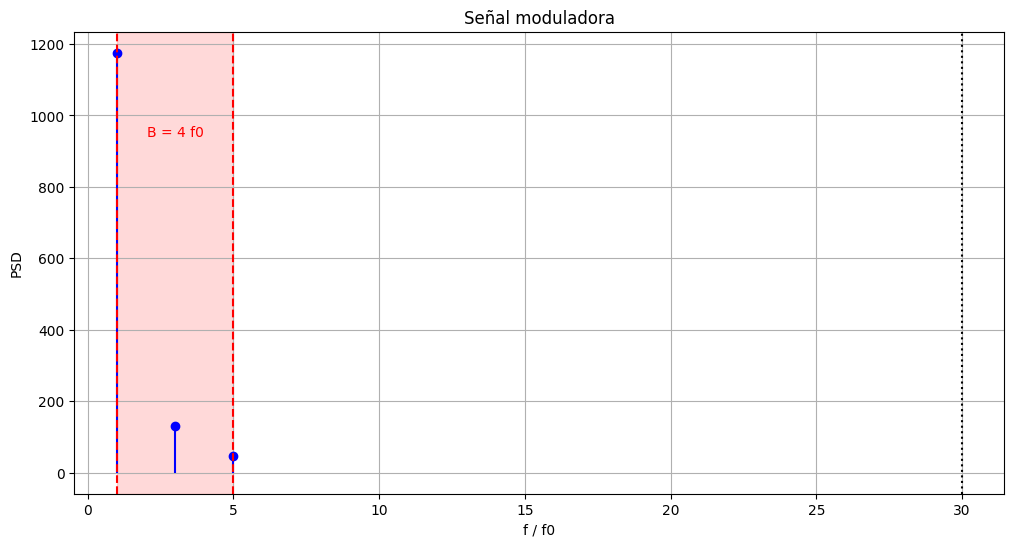

Moduladora: fmin=1, fmax=5, B=4 f0


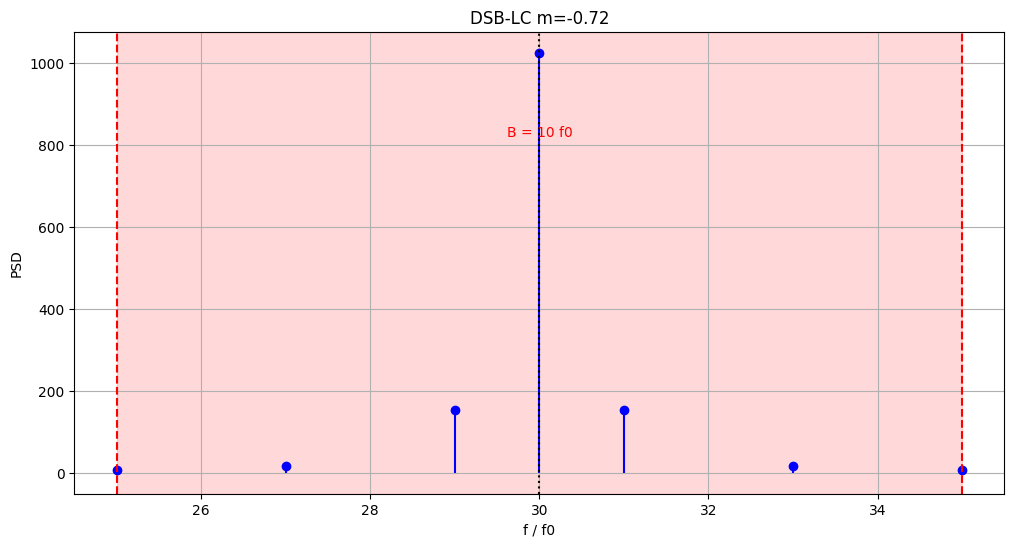

DSB-LC m=-0.72: fmin=25, fmax=35, B=10 f0


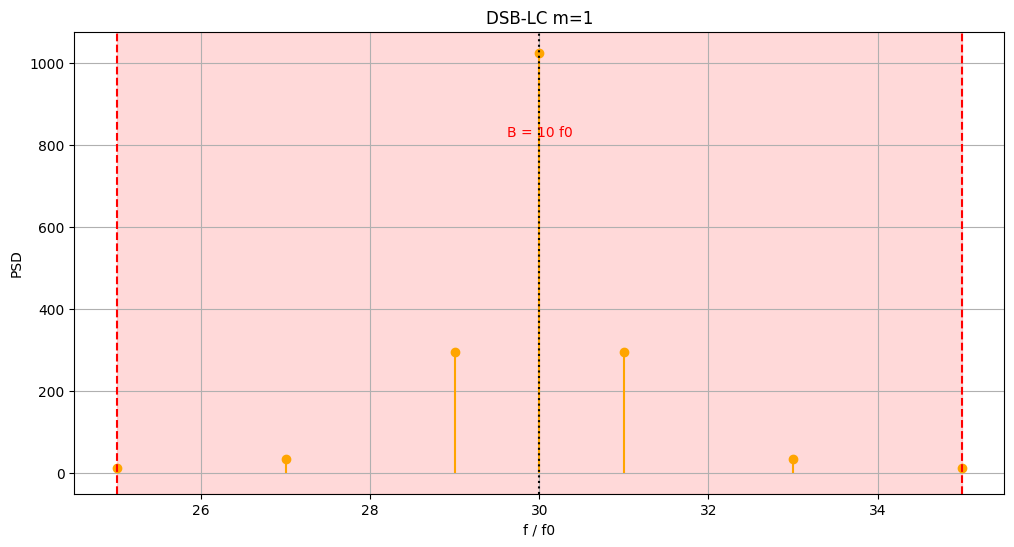

DSB-LC m=1: fmin=25, fmax=35, B=10 f0


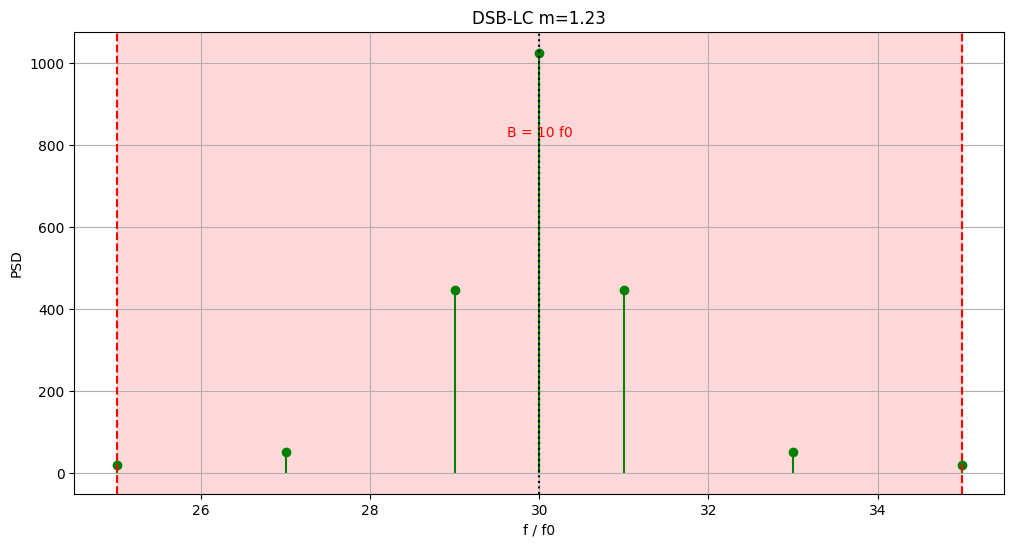

DSB-LC m=1.23: fmin=25, fmax=35, B=10 f0


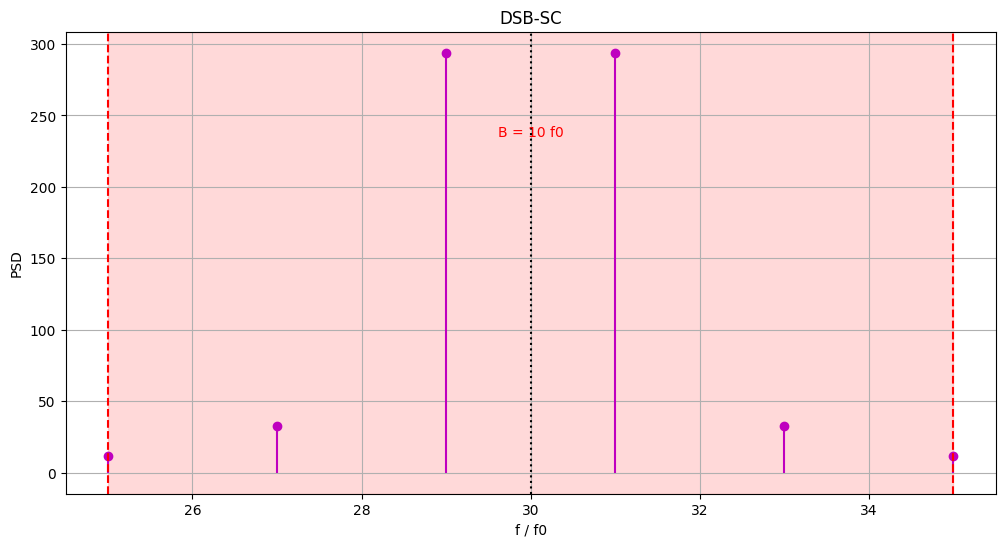

DSB-SC: fmin=25, fmax=35, B=10 f0


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS
# =========================================================
N = 4096
n = np.arange(N)

f0 = 1/N
w0 = 2*np.pi/N

fc = 30*f0

M = 3
HM = [2*k+1 for k in range(M)]  # [1,3,5]

# =========================================================
# FUNCIONES
# =========================================================
def generar_senal_moduladora(n, HM, w0):
    x = np.zeros_like(n, dtype=float)
    for k in HM:
        x += (1/k)*np.sin(k*w0*n)
    return (4/np.pi)*x

def normalizar(x):
    return x / np.max(np.abs(x))

def generar_portadora(n, fc):
    return np.cos(2*np.pi*fc*n)

def dsb_lc(xn, carrier, m):
    return (1 + m*xn)*carrier

def dsb_sc(xn, carrier):
    return xn*carrier

def calcular_psd(s):
    S = np.fft.fft(s)
    S = np.fft.fftshift(S)
    return (np.abs(S)**2)/len(s)

def eje_frecuencia(N):
    return np.arange(-N//2, N//2)

def medir_bw(k, psd, eps=1e-8):
    mask = psd > eps*np.max(psd)
    k_sig = k[mask]
    k_sig = k_sig[k_sig >= 0]
    k_sig = np.sort(k_sig)

    fmin = k_sig[0]
    fmax = k_sig[-1]
    B = fmax - fmin

    return fmin, fmax, B

def graficar_psd_bw(k, psd, titulo, color):
    # Parte positiva
    mask_pos = k >= 0
    k_pos = k[mask_pos]
    psd_pos = psd[mask_pos]

    # Medición
    fmin, fmax, B = medir_bw(k, psd)

    # Componentes significativas
    mask = psd_pos > 1e-8*np.max(psd_pos)

    plt.figure(figsize=(12,6))

    markerline, stemlines, baseline = plt.stem(
        k_pos[mask], psd_pos[mask],
        basefmt=" "
    )

    plt.setp(markerline, marker='o', color=color)
    plt.setp(stemlines, color=color)

    # Líneas BW
    plt.axvline(fmin, color='r', linestyle='--')
    plt.axvline(fmax, color='r', linestyle='--')

    # Región BW
    plt.axvspan(fmin, fmax, color='red', alpha=0.15)

    # Portadora (si aplica)
    plt.axvline(30, color='k', linestyle=':')

    # Texto
    plt.text((fmin+fmax)/2, max(psd_pos)*0.8,
             f'B = {B} f0',
             ha='center', color='red')

    plt.title(titulo)
    plt.xlabel('f / f0')
    plt.ylabel('PSD')
    plt.grid()

    plt.show()

    return fmin, fmax, B


# =========================================================
# ETAPA 1: MODULADORA
# =========================================================
x = generar_senal_moduladora(n, HM, w0)
xn = normalizar(x)

# =========================================================
# ETAPA 2: MODULACIÓN
# =========================================================
carrier = generar_portadora(n, fc)

m_values = [-0.72, 1, 1.23]

s_LC = [dsb_lc(xn, carrier, m) for m in m_values]
s_SC = dsb_sc(xn, carrier)

# =========================================================
# PSD
# =========================================================
k = eje_frecuencia(N)

psd_x = calcular_psd(xn)
psd_LC = [calcular_psd(s) for s in s_LC]
psd_SC = calcular_psd(s_SC)

# =========================================================
# MEDICIÓN Y GRÁFICAS
# =========================================================
print("\n====== RESULTADOS ======\n")

# Moduladora
fmin_x, fmax_x, Bx = graficar_psd_bw(k, psd_x, 'Señal moduladora', 'b')
print(f"Moduladora: fmin={fmin_x}, fmax={fmax_x}, B={Bx} f0")

# DSB-LC
for i, psd in enumerate(psd_LC):
    fmin, fmax, B = graficar_psd_bw(
        k, psd,
        f'DSB-LC m={m_values[i]}',
        ['b','orange','g'][i]
    )
    print(f"DSB-LC m={m_values[i]}: fmin={fmin}, fmax={fmax}, B={B} f0")

# DSB-SC
fmin_sc, fmax_sc, B_sc = graficar_psd_bw(k, psd_SC, 'DSB-SC', 'm')
print(f"DSB-SC: fmin={fmin_sc}, fmax={fmax_sc}, B={B_sc} f0")

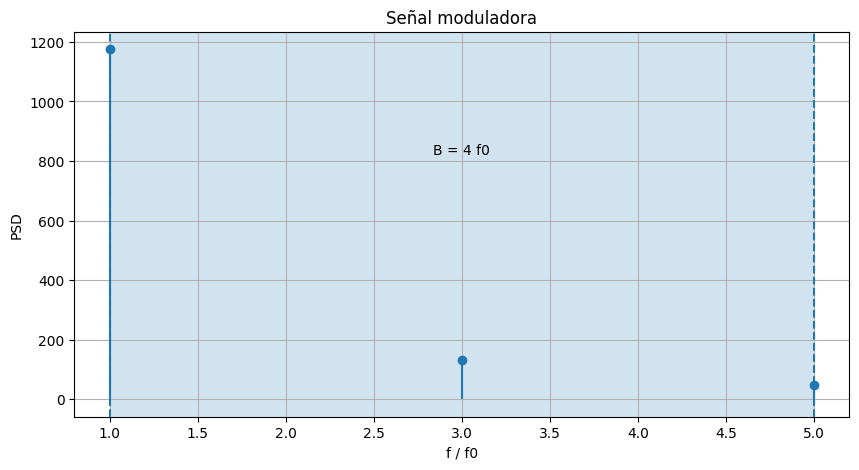

Señal moduladora:
  f_min = 1
  f_max = 5
  Ancho de banda = 4 f0



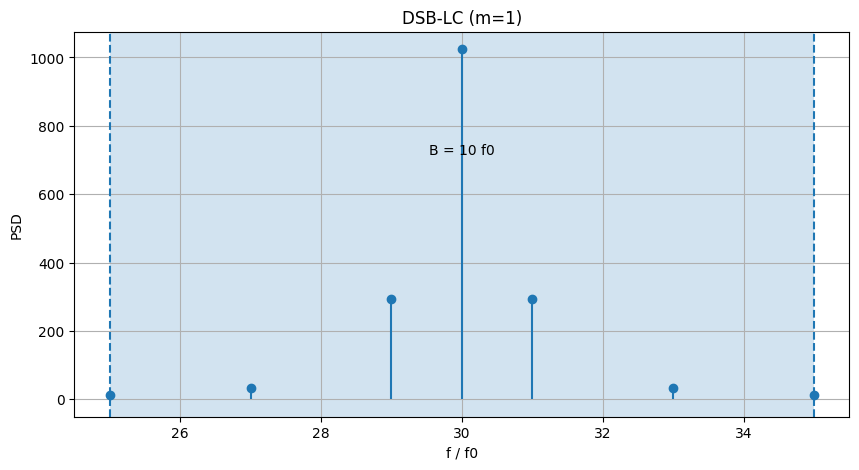

DSB-LC (m=1):
  f_min = 25
  f_max = 35
  Ancho de banda = 10 f0



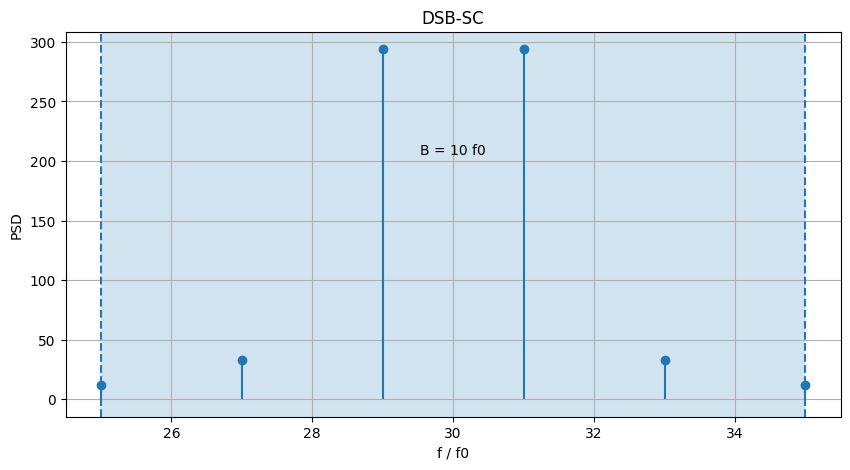

DSB-SC:
  f_min = 25
  f_max = 35
  Ancho de banda = 10 f0



In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARÁMETROS
# =========================
N = 4096
n = np.arange(N)

f0 = 1/N
w0 = 2*np.pi/N
fc = 30*f0

# =========================
# SEÑAL MODULADORA
# =========================
x = (4/np.pi)*(
    np.sin(w0*n) +
    (1/3)*np.sin(3*w0*n) +
    (1/5)*np.sin(5*w0*n)
)

xn = x / np.max(np.abs(x))

# =========================
# PORTADORA
# =========================
carrier = np.cos(2*np.pi*fc*n)

# =========================
# MODULACIÓN
# =========================
m = 1
s_LC = (1 + m*xn)*carrier
s_SC = xn*carrier

# =========================
# PSD
# =========================
def PSD(signal):
    S = np.fft.fft(signal)
    S = np.fft.fftshift(S)
    return (np.abs(S)**2)/len(signal)

k = np.arange(-N//2, N//2)

psd_x = PSD(xn)
psd_LC = PSD(s_LC)
psd_SC = PSD(s_SC)

# =========================
# FUNCIÓN SIMPLE DE BW
# =========================
def ancho_banda_simple(k, psd):
    mask = psd > 1e-8*np.max(psd)
    k_sig = k[mask]
    k_sig = k_sig[k_sig >= 0]

    fmin = np.min(k_sig)
    fmax = np.max(k_sig)
    B = fmax - fmin

    return fmin, fmax, B

# =========================
# FUNCIÓN DE GRÁFICA
# =========================
def plot_psd_simple(k, psd, titulo, color):

    # Solo frecuencias positivas
    mask_pos = k >= 0
    k_pos = k[mask_pos]
    psd_pos = psd[mask_pos]

    # Calcular BW
    fmin, fmax, B = ancho_banda_simple(k, psd)

    # Componentes importantes
    mask = psd_pos > 1e-8*np.max(psd_pos)

    plt.figure(figsize=(10,5))

    plt.stem(k_pos[mask], psd_pos[mask], basefmt=" ")

    # Líneas BW
    plt.axvline(fmin, linestyle='--')
    plt.axvline(fmax, linestyle='--')

    # Zona BW
    plt.axvspan(fmin, fmax, alpha=0.2)

    # Texto
    plt.text((fmin+fmax)/2, max(psd_pos)*0.7,
             f'B = {B} f0',
             ha='center')

    plt.title(titulo)
    plt.xlabel('f / f0')
    plt.ylabel('PSD')
    plt.grid()

    plt.show()

    # Print claro
    print(f"{titulo}:")
    print(f"  f_min = {fmin}")
    print(f"  f_max = {fmax}")
    print(f"  Ancho de banda = {B} f0\n")


# =========================
# RESULTADOS
# =========================

plot_psd_simple(k, psd_x, "Señal moduladora", "b")
plot_psd_simple(k, psd_LC, "DSB-LC (m=1)", "orange")
plot_psd_simple(k, psd_SC, "DSB-SC", "m")

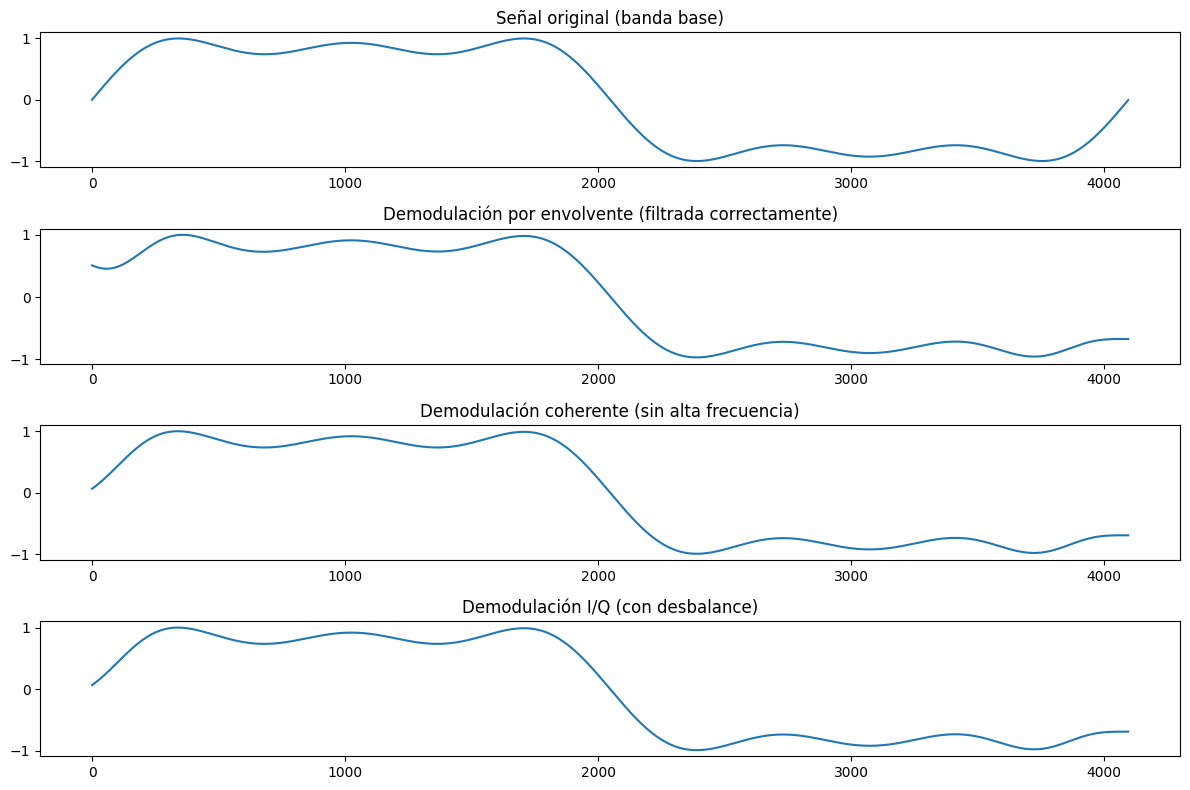

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# =========================================================
# PARÁMETROS
# =========================================================
N = 4096
n = np.arange(N)

fs = 1.0                 # Frecuencia de muestreo normalizada
f0 = 1/N
w0 = 2*np.pi/N
fc = 30*f0

# =========================================================
# SEÑAL MODULADORA
# =========================================================
x = (4/np.pi)*(np.sin(w0*n) + (1/3)*np.sin(3*w0*n) + (1/5)*np.sin(5*w0*n))
xn = x / np.max(np.abs(x))

# =========================================================
# MODULACIÓN
# =========================================================
carrier = np.cos(2*np.pi*fc*n)

m = 1
s_LC = (1 + m*xn)*carrier
s_SC = xn * carrier

# =========================================================
# FILTRO PASA BAJAS CORRECTO
# =========================================================
def lowpass(signal, cutoff_hz, fs):
    nyq = fs / 2
    Wn = cutoff_hz / nyq
    b, a = butter(4, Wn)
    return filtfilt(b, a, signal)

cutoff = 10*f0   # ligeramente mayor que 5f0

# =========================================================
# 1. DEMODULACIÓN POR ENVOLVENTE (CORREGIDA)
# =========================================================
env = np.abs(s_LC)
env_lp = lowpass(env, cutoff, fs)

x_env = (env_lp - np.mean(env_lp)) / m

# =========================================================
# 2. DEMODULACIÓN COHERENTE (CORREGIDA)
# =========================================================
z = s_SC * np.cos(2*np.pi*fc*n)
x_coh = lowpass(z, cutoff, fs)

# =========================================================
# 3. DEMODULACIÓN IQ (CON DESBALANCE)
# =========================================================
I = s_SC * np.cos(2*np.pi*fc*n)
Q = s_SC * np.sin(2*np.pi*fc*n)

a = 1.0
b = 0.7   # desbalance

z_iq = a*I + 1j*b*Q
x_iq = np.real(lowpass(z_iq, cutoff, fs))

# =========================================================
# NORMALIZAR PARA COMPARAR
# =========================================================
def norm(x):
    return x / np.max(np.abs(x))

xn_plot = norm(xn)
x_env_plot = norm(x_env)
x_coh_plot = norm(x_coh)
x_iq_plot = norm(x_iq)

# =========================================================
# GRÁFICAS (COMPARACIÓN REAL)
# =========================================================
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(xn_plot)
plt.title("Señal original (banda base)")

plt.subplot(4,1,2)
plt.plot(x_env_plot)
plt.title("Demodulación por envolvente (filtrada correctamente)")

plt.subplot(4,1,3)
plt.plot(x_coh_plot)
plt.title("Demodulación coherente (sin alta frecuencia)")

plt.subplot(4,1,4)
plt.plot(x_iq_plot)
plt.title("Demodulación I/Q (con desbalance)")

plt.tight_layout()
plt.show()

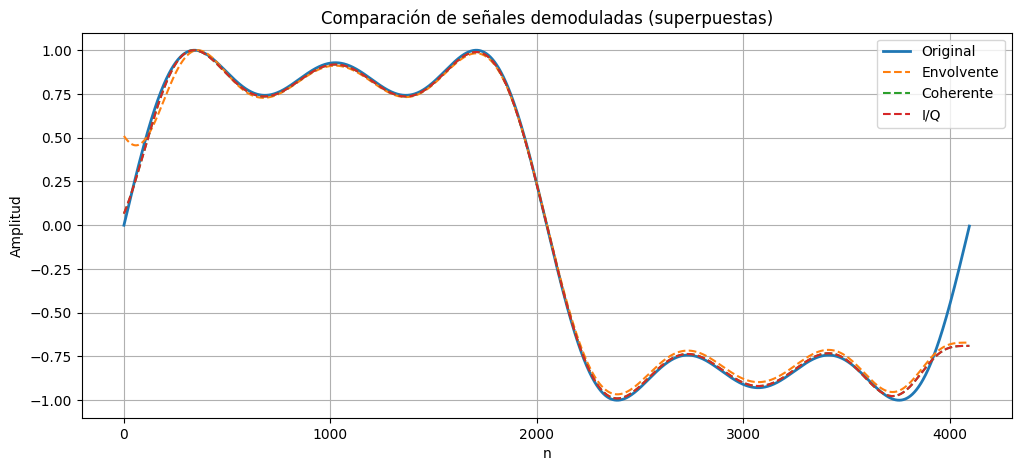


===== ANCHO DE BANDA =====

Original:
  f_min = 1
  f_max = 5
  B = 4 f0

Envolvente:
  f_min = 1
  f_max = 2047
  B = 2046 f0

Coherente:
  f_min = 0
  f_max = 2047
  B = 2047 f0

IQ:
  f_min = 0
  f_max = 2047
  B = 2047 f0



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# =========================================================
# PARÁMETROS
# =========================================================
N = 4096
n = np.arange(N)

fs = 1.0
f0 = 1/N
w0 = 2*np.pi/N
fc = 30*f0

# =========================================================
# SEÑAL MODULADORA
# =========================================================
x = (4/np.pi)*(np.sin(w0*n) + (1/3)*np.sin(3*w0*n) + (1/5)*np.sin(5*w0*n))
xn = x / np.max(np.abs(x))

# =========================================================
# MODULACIÓN
# =========================================================
carrier = np.cos(2*np.pi*fc*n)

m = 1
s_LC = (1 + m*xn)*carrier
s_SC = xn * carrier

# =========================================================
# FILTRO PASA BAJAS CORRECTO
# =========================================================
def lowpass(signal, cutoff_hz, fs):
    nyq = fs / 2
    Wn = cutoff_hz / nyq
    b, a = butter(4, Wn)
    return filtfilt(b, a, signal)

cutoff = 10*f0

# =========================================================
# DEMODULACIONES
# =========================================================

# ---- Envolvente ----
env = np.abs(s_LC)
env_lp = lowpass(env, cutoff, fs)
x_env = (env_lp - np.mean(env_lp)) / m

# ---- Coherente ----
z = s_SC * np.cos(2*np.pi*fc*n)
x_coh = lowpass(z, cutoff, fs)

# ---- IQ ----
I = s_SC * np.cos(2*np.pi*fc*n)
Q = s_SC * np.sin(2*np.pi*fc*n)

a = 1.0
b = 0.7

z_iq = a*I + 1j*b*Q
x_iq = np.real(lowpass(z_iq, cutoff, fs))

# =========================================================
# NORMALIZAR (IMPORTANTE PARA COMPARAR)
# =========================================================
def norm(x):
    return x / np.max(np.abs(x))

xn_n = norm(xn)
x_env_n = norm(x_env)
x_coh_n = norm(x_coh)
x_iq_n = norm(x_iq)

# =========================================================
# GRÁFICA SUPERPUESTA
# =========================================================
plt.figure(figsize=(12,5))

plt.plot(xn_n, label='Original', linewidth=2)
plt.plot(x_env_n, '--', label='Envolvente')
plt.plot(x_coh_n, '--', label='Coherente')
plt.plot(x_iq_n, '--', label='I/Q')

plt.title("Comparación de señales demoduladas (superpuestas)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()

plt.show()

print("\n===== ANCHO DE BANDA =====\n")

#_____________________________
# =========================
# PSD
# =========================
def PSD(signal):
    S = np.fft.fft(signal)
    S = np.fft.fftshift(S)
    return (np.abs(S)**2)/len(signal)

k = np.arange(-N//2, N//2)

# =========================
# ANCHO DE BANDA
# =========================
def ancho_banda(k, psd, eps=1e-8):
    mask = psd > eps*np.max(psd)
    k_sig = k[mask]

    # Solo positivas
    k_sig = k_sig[k_sig >= 0]
    k_sig = np.sort(k_sig)

    fmin = k_sig[0]
    fmax = k_sig[-1]
    B = fmax - fmin

    return fmin, fmax, B

# Lista de señales
signals = [
    ("Original", xn),
    ("Envolvente", x_env),
    ("Coherente", x_coh),
    ("IQ", x_iq)
]

for name, sig in signals:
    psd = PSD(sig)
    fmin, fmax, B = ancho_banda(k, psd)

    print(f"{name}:")
    print(f"  f_min = {fmin}")
    print(f"  f_max = {fmax}")
    print(f"  B = {B} f0\n")

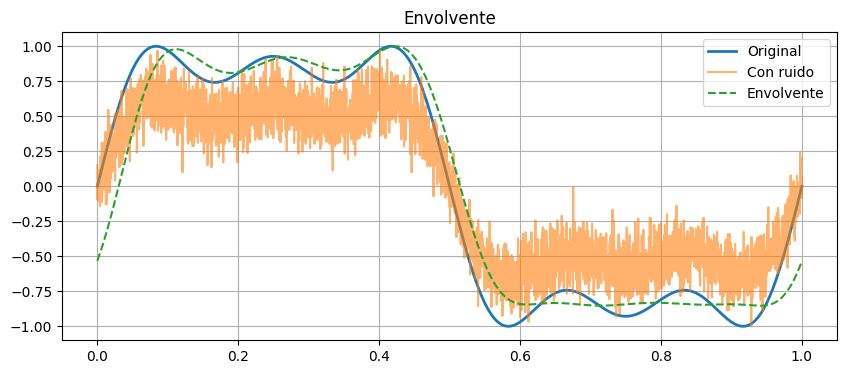

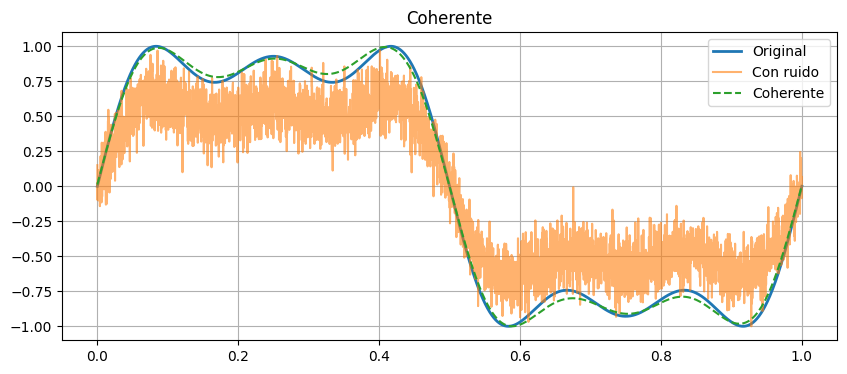

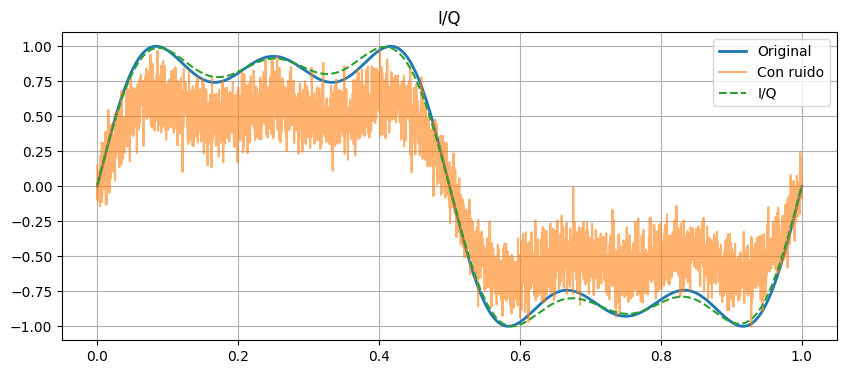


===== ANCHO DE BANDA =====

Moduladora (ruido): 3.00 Hz
Modulada:           0.00 Hz
Envolvente:         3.00 Hz
Coherente:          3.00 Hz
I/Q:                3.00 Hz


In [27]:
import torch
import matplotlib.pyplot as plt

# ==============================
# 1. PARÁMETROS
# ==============================
N = 4096
t = torch.linspace(0, 1, N)
fs = N  # Hz

f0 = 1      # Hz
fc = 30     # Hz

w0 = 2 * torch.pi * f0
wc = 2 * torch.pi * fc

# ==============================
# 2. SEÑAL MODULADORA
# ==============================
m = (4/torch.pi) * (
    torch.sin(w0*t) +
    (1/3)*torch.sin(3*w0*t) +
    (1/5)*torch.sin(5*w0*t)
)

# ==============================
# 3. RUIDO AWGN
# ==============================
sigma2 = 0.05
noise = torch.randn(N) * torch.sqrt(torch.tensor(sigma2))
m_noisy = m + noise

# ==============================
# 4. MODULACIÓN DSB-LC
# ==============================
Ac = 1
mu = 1

s = Ac * (1 + mu*m_noisy) * torch.cos(wc*t)

# ==============================
# 5. FILTRO GAUSSIANO (MEJORADO)
# ==============================
def lowpass(x, cutoff):
    X = torch.fft.fft(x)
    freq = torch.fft.fftfreq(len(x), d=1/fs)

    # Filtro gaussiano
    H = torch.exp(-(freq/cutoff)**4)

    return torch.fft.ifft(X * H).real

# ==============================
# 6. DEMODULACIÓN ENVOLVENTE
# ==============================
RC = 0.02
alpha = 1 / (1 + RC * fs)

y_env = torch.abs(s)

y_env_rc = torch.zeros_like(y_env)
for i in range(1, len(y_env)):
    y_env_rc[i] = alpha * y_env[i] + (1 - alpha) * y_env_rc[i-1]

y_env_f = lowpass(y_env_rc, cutoff=8)
y_env_final = y_env_f - torch.mean(y_env_f)

# ==============================
# 7. DEMODULACIÓN COHERENTE
# ==============================
phi = 0.02

y_sync = s * torch.cos(wc*t + phi)
y_sync = lowpass(y_sync, cutoff=8)
y_sync = y_sync - torch.mean(y_sync)
y_sync = 2 * y_sync

# ==============================
# 8. DEMODULACIÓN I/Q
# ==============================
epsilon = 0.2
phi_iq = 0.05

I = s * torch.cos(wc*t)
Q = s * torch.sin(wc*t)

# Desbalance + error de fase
I_p = (1 + epsilon) * I
Q_p = (1 - epsilon) * (Q * torch.cos(torch.tensor(phi_iq)) +
                      I * torch.sin(torch.tensor(phi_iq)))

I_f = lowpass(I_p, cutoff=8)
Q_f = lowpass(Q_p, cutoff=8)

y_iq = I_f - torch.mean(I_f)

# ==============================
# 9. NORMALIZACIÓN
# ==============================
def normalize(x):
    return x / torch.max(torch.abs(x))

m_n = normalize(m)
m_noisy_n = normalize(m_noisy)
env_n = normalize(y_env_final)
sync_n = normalize(y_sync)
iq_n = normalize(y_iq)

# ==============================
# 10. GRÁFICAS
# ==============================
def plot_compare(title, y):
    plt.figure(figsize=(10,4))
    plt.plot(t.numpy(), m_n.numpy(), label="Original", linewidth=2)
    plt.plot(t.numpy(), m_noisy_n.numpy(), label="Con ruido", alpha=0.6)
    plt.plot(t.numpy(), y.numpy(), '--', label=title)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

plot_compare("Envolvente", env_n)
plot_compare("Coherente", sync_n)
plot_compare("I/Q", iq_n)

# ==============================
# 11. PSD
# ==============================
def compute_psd(x):
    X = torch.fft.fft(x)
    return torch.fft.fftshift(torch.abs(X)**2)

freq = torch.fft.fftfreq(N, d=1/fs)
freq_shift = torch.fft.fftshift(freq)

PSD_m = compute_psd(m_noisy)
PSD_s = compute_psd(s)
PSD_env = compute_psd(y_env_final)
PSD_sync = compute_psd(y_sync)
PSD_iq = compute_psd(y_iq)

# ==============================
# 12. ANCHO DE BANDA (ROBUSTO)
# ==============================
def estimate_bandwidth(freq, PSD, baseband=True, threshold=0.05):
    PSD_norm = PSD / torch.max(PSD)

    mask = freq >= 0
    f_pos = freq[mask]
    PSD_pos = PSD_norm[mask]

    peaks = []

    for i in range(1, len(PSD_pos)-1):
        if PSD_pos[i] > PSD_pos[i-1] and PSD_pos[i] > PSD_pos[i+1]:
            if PSD_pos[i] > threshold:
                peaks.append(f_pos[i])

    if len(peaks) == 0:
        return 0.0

    peaks = torch.tensor(peaks)

    f_max = torch.max(peaks)
    f_min = torch.min(peaks)

    return f_max.item() if baseband else (f_max - f_min).item()

# ==============================
# 13. RESULTADOS
# ==============================
print("\n===== ANCHO DE BANDA =====\n")

print(f"Moduladora (ruido): {estimate_bandwidth(freq_shift, PSD_m, True):.2f} Hz")
print(f"Modulada:           {estimate_bandwidth(freq_shift, PSD_s, False):.2f} Hz")
print(f"Envolvente:         {estimate_bandwidth(freq_shift, PSD_env, True):.2f} Hz")
print(f"Coherente:          {estimate_bandwidth(freq_shift, PSD_sync, True):.2f} Hz")
print(f"I/Q:                {estimate_bandwidth(freq_shift, PSD_iq, True):.2f} Hz")

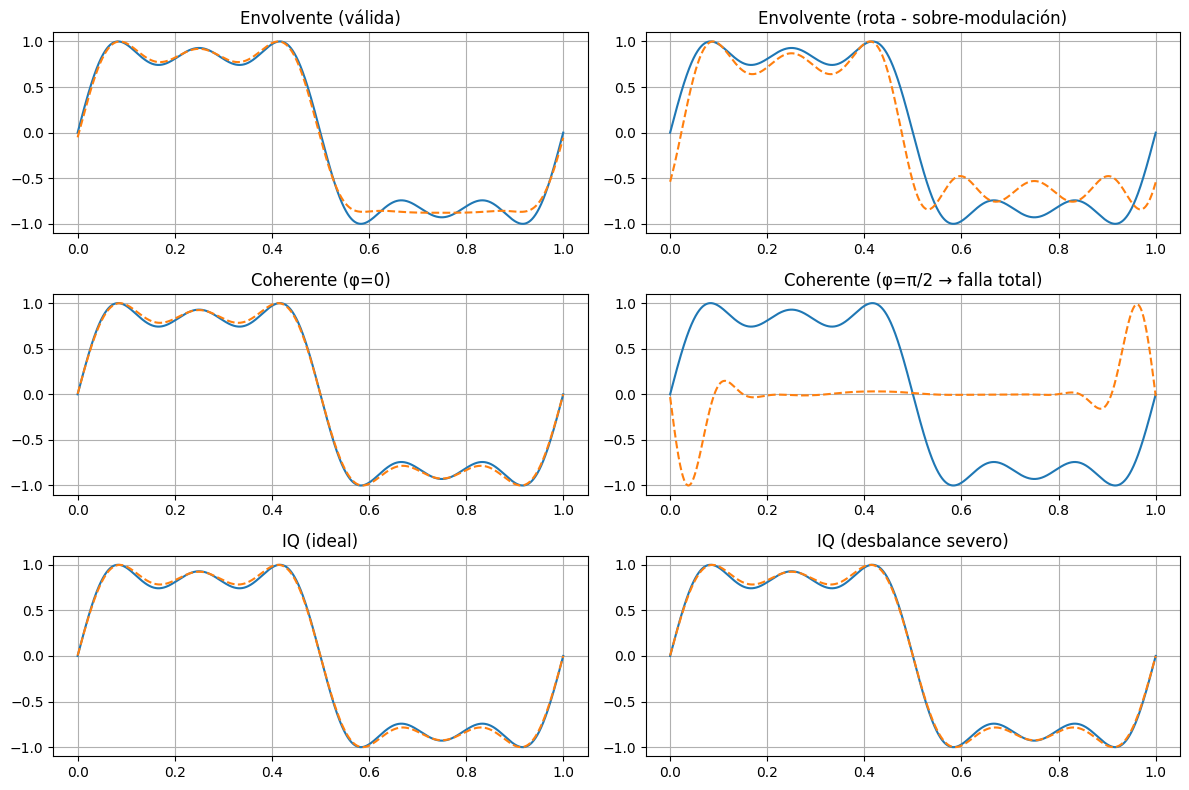

In [30]:
import torch
import matplotlib.pyplot as plt

# ==============================
# PARÁMETROS
# ==============================
N = 4096
t = torch.linspace(0, 1, N)
fs = N

f0 = 1
fc = 30

w0 = 2 * torch.pi * f0
wc = 2 * torch.pi * fc

# ==============================
# SEÑAL MODULADORA
# ==============================
m = (4/torch.pi) * (
    torch.sin(w0*t) +
    (1/3)*torch.sin(3*w0*t) +
    (1/5)*torch.sin(5*w0*t)
)

# ==============================
# FILTRO
# ==============================
def lowpass(x, cutoff=8):
    X = torch.fft.fft(x)
    freq = torch.fft.fftfreq(len(x), d=1/fs)
    H = torch.exp(-(freq/cutoff)**4)
    return torch.fft.ifft(X * H).real

# ==============================
# MODULACIÓN
# ==============================
Ac = 1

# ✔ Ideal
mu_ok = 1
s_ok = Ac * (1 + mu_ok*m) * torch.cos(wc*t)

# ❌ Rompiendo envolvente
mu_bad = 2.0
s_bad_env = Ac * (1 + mu_bad*m) * torch.cos(wc*t)

# ==============================
# DEMODULACIÓN
# ==============================

# -------- ENVOLVENTE --------
def demod_env(s):
    env = torch.abs(s)
    return lowpass(env) - torch.mean(env)

# -------- COHERENTE --------
def demod_sync(s, phi):
    y = s * torch.cos(wc*t + phi)
    y = lowpass(y)
    y = y - torch.mean(y)
    return 2*y

# -------- IQ --------
def demod_iq(s, epsilon, phi):
    I = s * torch.cos(wc*t)
    Q = s * torch.sin(wc*t)

    I_p = (1 + epsilon) * I
    Q_p = (1 - epsilon) * (Q * torch.cos(torch.tensor(phi)) +
                          I * torch.sin(torch.tensor(phi)))

    I_f = lowpass(I_p)
    return I_f - torch.mean(I_f)

# ==============================
# CASOS
# ==============================

# ENV
env_ok = demod_env(s_ok)
env_bad = demod_env(s_bad_env)

# COHERENTE
sync_ok = demod_sync(s_ok, phi=0)
sync_bad = demod_sync(s_ok, phi=torch.pi/2)  # 🔥 destruye señal

# IQ
iq_ok = demod_iq(s_ok, epsilon=0, phi=0)
iq_bad = demod_iq(s_ok, epsilon=1.0, phi=torch.pi/4)  # 🔥 fuerte desbalance

# ==============================
# NORMALIZAR
# ==============================
def norm(x):
    return x / torch.max(torch.abs(x))

m_n = norm(m)

env_ok = norm(env_ok)
env_bad = norm(env_bad)

sync_ok = norm(sync_ok)
sync_bad = norm(sync_bad)

iq_ok = norm(iq_ok)
iq_bad = norm(iq_bad)

# ==============================
# GRÁFICA 3x2 (REALMENTE DIFERENTE)
# ==============================
fig, axs = plt.subplots(3, 2, figsize=(12, 8))

# -------- ENV --------
axs[0,0].plot(t.numpy(), m_n.numpy())
axs[0,0].plot(t.numpy(), env_ok.numpy(), '--')
axs[0,0].set_title("Envolvente (válida)")
axs[0,0].grid()

axs[0,1].plot(t.numpy(), m_n.numpy())
axs[0,1].plot(t.numpy(), env_bad.numpy(), '--')
axs[0,1].set_title("Envolvente (rota - sobre-modulación)")
axs[0,1].grid()

# -------- COHERENTE --------
axs[1,0].plot(t.numpy(), m_n.numpy())
axs[1,0].plot(t.numpy(), sync_ok.numpy(), '--')
axs[1,0].set_title("Coherente (φ=0)")
axs[1,0].grid()

axs[1,1].plot(t.numpy(), m_n.numpy())
axs[1,1].plot(t.numpy(), sync_bad.numpy(), '--')
axs[1,1].set_title("Coherente (φ=π/2 → falla total)")
axs[1,1].grid()

# -------- IQ --------
axs[2,0].plot(t.numpy(), m_n.numpy())
axs[2,0].plot(t.numpy(), iq_ok.numpy(), '--')
axs[2,0].set_title("IQ (ideal)")
axs[2,0].grid()

axs[2,1].plot(t.numpy(), m_n.numpy())
axs[2,1].plot(t.numpy(), iq_bad.numpy(), '--')
axs[2,1].set_title("IQ (desbalance severo)")
axs[2,1].grid()

plt.tight_layout()
plt.show()